In [1]:
import pandas as pd
import numpy as np

df_tweets = pd.read_pickle('crypto_tweets_2022_to_2025')
px = pd.read_pickle('crypto_data_2022_to_2025')
ret = pd.read_pickle('crypto_returns_2022_to_2025')

In [ ]:
start_time = '2022-01-01T00:00:00Z'
end_time = '2025-01-01T00:00:00Z'

from binance.client import Client as bnb_client
import pandas as pd

cols = ['close', 'volume', 'quote_volume', 'num_trades', 'taker_base_volume', 'taker_quote_volume']

client = bnb_client(tld='US')
def get_binance_px(symbol, freq, start, end):
    data = client.get_historical_klines(symbol, freq, start, end)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    
    # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    data['open_time'] = pd.to_datetime(data['open_time'], unit='ms')
    data['close_time'] = pd.to_datetime(data['close_time'], unit='ms')
    data = data.set_index('open_time')
    return data 

univ = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'BNBUSDT']

freq = '1h'
px = pd.DataFrame().astype(float)

all_data = []
for x in univ:
    data = get_binance_px(x ,freq, start_time, end_time)
    data = data[cols]
    data.columns = pd.MultiIndex.from_product([[x], data.columns])
    all_data.append(data)

px = pd.concat(all_data, axis=1)
px = px.reindex(pd.date_range(px.index[0],px.index[-1],freq=freq))

In [128]:
ret = px.xs('close', axis=1, level=1).astype(float).pct_change()

/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_4446/1912466777.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = px.xs('close', axis=1, level=1).astype(float).pct_change()


In [167]:
ret.to_pickle('crypto_returns_2022_to_2025')

In [ ]:
px = px.astype(float)
px.to_pickle('crypto_data_2022_to_2025')

<Axes: >

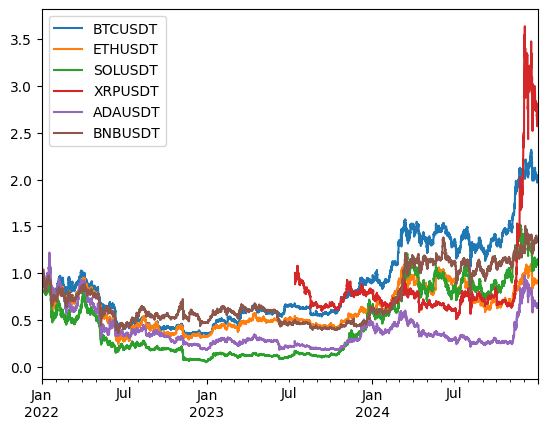

In [6]:
(1+ret).cumprod().plot()

In [60]:
from xdk import Client
import pandas as pd
import numpy as np

client = Client(bearer_token="AAAAAAAAAAAAAAAAAAAAAKZX8gEAAAAAKEtxgn4Z2DU9yHk3WI2xMW4p%2BKo%3DGiZFyIcHOEd9FE0d1FuNMAQ8ZLyEFFdcg9OLoZ9OJgNerNRkID")

granularity = 'hour'

# Count past bitcoin-related posts
btc_posts = client.posts.get_counts_all(
    query="(bitcoin OR btc) lang:en -is:retweet",
    start_time=start_time,
    end_time=end_time,
    granularity=granularity
)

# Count past ethereum-related posts
eth_posts = client.posts.get_counts_all(
    query="(ethereum OR eth) lang:en -is:retweet",
    start_time=start_time,
    end_time=end_time,
    granularity=granularity
)

# Count past altcoin-related posts
altcoin_posts = client.posts.get_counts_all(
    query='("binance coin" OR BNB solana OR SOL OR cardano OR ADA OR ripple OR XRP OR tron) lang:en -is:retweet',
    start_time=start_time,
    end_time=end_time,
    granularity=granularity
)

In [ ]:
df_tweets = {'start_date':[], 'end_date': [], 'btc_count':[], 'eth_count':[], 'alt_count':[]}
for page in btc_posts:
    pageData = page.data
    for data in pageData:
        df_tweets['start_date'].append(data['start'])
        df_tweets['end_date'].append(data['end'])
        df_tweets['btc_count'].append(data['tweet_count'])
        
for page in eth_posts:
    pageData = page.data
    for data in pageData:
        df_tweets['eth_count'].append(data['tweet_count'])
        
for page in altcoin_posts:
    pageData = page.data
    for data in pageData:
        df_tweets['alt_count'].append(data['tweet_count'])

In [63]:
df_tweets = pd.DataFrame(df_tweets)

In [ ]:
df_tweets['start_date'] = pd.to_datetime(df_tweets['start_date'])
df_tweets['end_date'] = pd.to_datetime(df_tweets['end_date'])
df_tweets = df_tweets.set_index('start_date')

In [67]:
del df_tweets['end_date']

In [190]:
# df_tweets['btc_count'].plot()

In [191]:
# df_tweets['eth_count'].plot()

In [192]:
# df_tweets['alt_count'].plot()

In [ ]:
# df_tweets.index.name = None
# df_tweets = df_tweets.sort_index()
# df_tweets.index = df_tweets.index.tz_localize(None)
# df_tweets = df_tweets.resample('1h').sum()
# df_tweets.to_pickle('crypto_tweets_2022_to_2025')

In [ ]:
ret.corrwith(px.xs('volumne', axis=1, level=1))

BTCUSDT    0.007685
ETHUSDT   -0.009289
SOLUSDT    0.039878
XRPUSDT    0.109117
ADAUSDT    0.033389
BNBUSDT    0.044373
dtype: float64

In [189]:
px.xs('num_trades', axis=1, level=1).corrwith(px.xs('volume', axis=1, level=1))


BTCUSDT    0.830004
ETHUSDT    0.896438
SOLUSDT    0.711048
XRPUSDT    0.842842
ADAUSDT    0.876935
BNBUSDT    0.791051
dtype: float64

In [193]:
df_tweets.corrwith(ret)

ADAUSDT     NaN
BNBUSDT     NaN
BTCUSDT     NaN
ETHUSDT     NaN
SOLUSDT     NaN
XRPUSDT     NaN
alt_count   NaN
btc_count   NaN
eth_count   NaN
dtype: float64

In [220]:
window = 24
tweet_zscore = (df_tweets - df_tweets.rolling(window).mean()) / df_tweets.rolling(window).std()
tweet_zscore.tail()

,btc_count,eth_count,alt_count
2024-12-31 19:00:00,-0.997963,-0.179469,-0.701060
2024-12-31 20:00:00,-1.431936,0.683882,-0.883099
2024-12-31 21:00:00,-1.685330,0.302012,-0.972955
2024-12-31 22:00:00,-1.540542,-0.086047,-1.047460
2024-12-31 23:00:00,-1.772922,-0.226309,-1.494447


<Axes: >

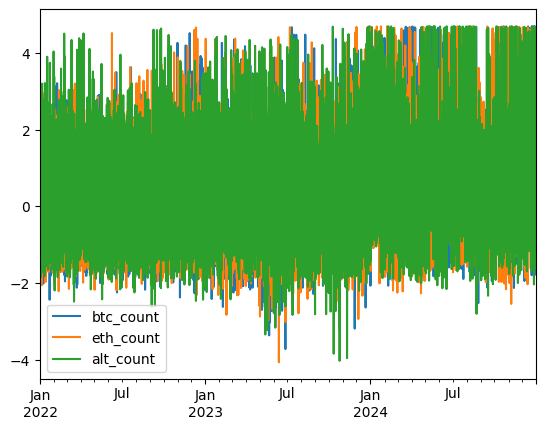

In [206]:
tweet_zscore.plot()

In [216]:
vol = ret.rolling(24).std()
vol.tail()

,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,ADAUSDT,BNBUSDT
2024-12-31 19:00:00,0.006765,0.007162,0.008408,0.009779,0.009845,0.005838
2024-12-31 20:00:00,0.006916,0.007166,0.008321,0.009706,0.009693,0.005858
2024-12-31 21:00:00,0.004997,0.005018,0.006585,0.007928,0.007530,0.004701
2024-12-31 22:00:00,0.004875,0.004623,0.006677,0.008135,0.007400,0.004326
2024-12-31 23:00:00,0.004871,0.004604,0.006801,0.007954,0.007298,0.004326


<Axes: >

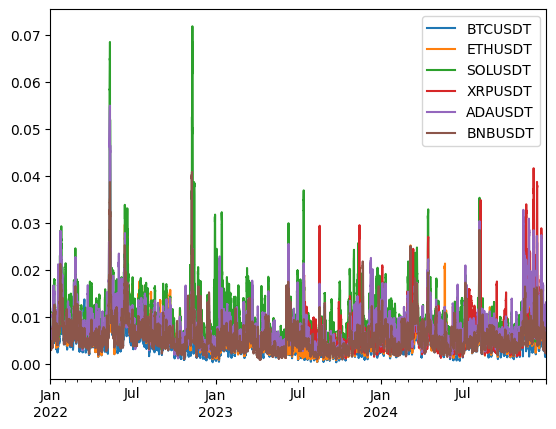

In [203]:
vol.plot()

In [209]:
tweet_zscore['btc_count'].corr(vol['BTCUSDT'])

np.float64(-0.009899575941542931)

In [221]:
fwd_ret = ret.shift(-1)
tweet_buckets = tweet_zscore.copy()
for col in df_tweets.columns:
    tweet_buckets[col] = pd.qcut(tweet_buckets[col], 5, labels=False, duplicates='drop')

In [226]:
tweet_buckets

,btc_count,eth_count,alt_count
2022-01-01 00:00:00,NaN,NaN,NaN
2022-01-01 01:00:00,NaN,NaN,NaN
2022-01-01 02:00:00,NaN,NaN,NaN
2022-01-01 03:00:00,NaN,NaN,NaN
2022-01-01 04:00:00,NaN,NaN,NaN
...,...,...,...
2024-12-31 19:00:00,0.0,2.0,1.0
2024-12-31 20:00:00,0.0,3.0,0.0
2024-12-31 21:00:00,0.0,3.0,0.0
2024-12-31 22:00:00,0.0,2.0,0.0


In [235]:
fwd_ret.groupby(tweet_buckets['btc_count']).mean()*100*24

,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,ADAUSDT,BNBUSDT
btc_count,,,,,,
0.0,0.035831,0.093839,0.411569,-0.109560,0.544065,0.248490
1.0,0.088204,0.085159,0.344172,0.143119,0.247145,0.232178
2.0,0.232930,-0.044147,0.408012,0.280117,-0.229737,0.099660
3.0,0.123926,-0.048880,-0.237502,0.914966,0.008977,-0.005174
4.0,0.019394,0.166015,-0.151673,0.201222,-0.290023,-0.165463


In [236]:
fwd_ret.groupby(tweet_buckets['eth_count']).mean()*100*24

,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,ADAUSDT,BNBUSDT
eth_count,,,,,,
0.0,0.156263,0.142105,0.339890,0.204635,0.159707,0.241887
1.0,0.189821,0.215858,0.706154,0.486122,0.218082,0.293951
2.0,0.199027,0.255659,0.371981,0.284557,0.311185,0.152081
3.0,0.348777,0.287432,0.087686,0.288487,0.047685,0.083514
4.0,-0.393595,-0.649046,-0.731126,0.056055,-0.456204,-0.361759


In [234]:
fwd_ret.groupby(tweet_buckets['alt_count']).mean()*100*24

,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,ADAUSDT,BNBUSDT
alt_count,,,,,,
0.0,0.241205,0.051295,0.252245,0.659429,-0.046942,-0.067410
1.0,0.204910,0.327995,0.377818,0.153813,0.281654,0.347576
2.0,-0.097433,-0.031850,-0.148162,0.003872,-0.259352,-0.075155
3.0,0.024441,-0.038246,-0.146965,-0.208159,-0.036455,0.083740
4.0,0.127162,-0.057208,0.439643,0.850367,0.341522,0.120940


In [2]:
volume = px.xs('volume', axis=1, level=1)
volume_zscore = (volume - volume.rolling(24).mean())/volume.rolling(24).std()

In [3]:
volume['BTCUSDT'].corr(df_tweets['btc_count'].shift(1))

np.float64(-0.046450058170381045)

In [4]:
taker_base = px.xs('taker_base_volume', axis=1, level=1).astype(float)
taker_ratio = taker_base / volume  # ratio close to 1 = buyers aggressive, 0 = sellers

In [5]:
taker_ratio

,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,ADAUSDT,BNBUSDT
2022-01-01 00:00:00,0.703504,0.411536,0.384047,NaN,0.636492,0.568565
2022-01-01 01:00:00,0.301512,0.530236,0.496703,NaN,0.529593,0.303015
2022-01-01 02:00:00,0.533727,0.325845,0.287080,NaN,0.306251,0.594659
2022-01-01 03:00:00,0.559907,0.243270,0.568888,NaN,0.604508,0.702683
2022-01-01 04:00:00,0.299893,0.452991,0.206185,NaN,0.137923,0.362854
...,...,...,...,...,...,...
2024-12-31 19:00:00,0.358243,0.962100,0.879809,0.906969,0.312957,0.396717
2024-12-31 20:00:00,0.660940,0.713732,0.806821,0.399391,0.149989,0.482766
2024-12-31 21:00:00,0.584532,0.438002,0.412045,0.510431,0.317709,0.874462
2024-12-31 22:00:00,0.418869,0.878008,0.498315,0.472689,0.086658,0.568386


In [6]:
high_volume = volume_zscore > 1
confirmed_rets = ret[high_volume]
confirmed_rets.mean()*24

BTCUSDT   -0.001783
ETHUSDT   -0.006981
SOLUSDT    0.005581
XRPUSDT    0.007300
ADAUSDT    0.003026
BNBUSDT    0.007691
dtype: float64

In [7]:
ret.mean()*24

BTCUSDT    0.001021
ETHUSDT    0.000515
SOLUSDT    0.001582
XRPUSDT    0.002758
ADAUSDT    0.000594
BNBUSDT    0.000836
dtype: float64

In [8]:
confirmed_rets.describe()

,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,ADAUSDT,BNBUSDT
count,3831.000000,3616.000000,3647.000000,1546.000000,3475.000000,3305.000000
mean,-0.000074,-0.000291,0.000233,0.000304,0.000126,0.000320
std,0.010549,0.013046,0.019250,0.016507,0.015311,0.011906
min,-0.070139,-0.100712,-0.196582,-0.125351,-0.127148,-0.099247
25%,-0.004919,-0.005849,-0.009462,-0.005054,-0.006567,-0.003701
50%,0.000000,-0.000228,-0.000136,0.000000,0.000000,0.000214
75%,0.004985,0.005300,0.009011,0.005130,0.006958,0.004732
max,0.065403,0.094002,0.161994,0.132483,0.137400,0.148803


In [9]:
ret.describe()

,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,ADAUSDT,BNBUSDT
count,26303.000000,26303.000000,26303.000000,12874.000000,26303.000000,26303.000000
mean,0.000043,0.000021,0.000066,0.000115,0.000025,0.000035
std,0.005675,0.007153,0.011170,0.008811,0.009175,0.006835
min,-0.070139,-0.100712,-0.196582,-0.125351,-0.127148,-0.099247
25%,-0.002050,-0.002613,-0.004911,-0.002986,-0.003899,-0.002636
50%,0.000059,0.000058,0.000000,0.000000,0.000000,0.000028
75%,0.002184,0.002719,0.004896,0.003232,0.004013,0.002872
max,0.065403,0.094002,0.161994,0.132483,0.137400,0.148803


In [10]:
high_alt_tweets = df_tweets['alt_count'] > df_tweets['alt_count'].rolling(24).mean().shift(1)

In [16]:
high_alt_tweets.head()

2022-01-01 00:00:00    False
2022-01-01 01:00:00    False
2022-01-01 02:00:00    False
2022-01-01 03:00:00    False
2022-01-01 04:00:00    False
Freq: h, Name: alt_count, dtype: bool

In [15]:
high_volume.head()

,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,ADAUSDT,BNBUSDT
2022-01-01 00:00:00,False,False,False,False,False,False
2022-01-01 01:00:00,False,False,False,False,False,False
2022-01-01 02:00:00,False,False,False,False,False,False
2022-01-01 03:00:00,False,False,False,False,False,False
2022-01-01 04:00:00,False,False,False,False,False,False


In [ ]:
high_alt_tweets.index = high_volume.index
combined_mask = high_volume & high_alt_tweets
# ret[combined_mask].mean()

In [11]:
ret[high_alt_tweets]

,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,ADAUSDT,BNBUSDT
2022-01-02 01:00:00,-0.005678,-0.004599,-0.004025,NaN,-0.016437,-0.004786
2022-01-03 04:00:00,0.000327,0.001900,-0.004987,NaN,-0.001385,-0.001446
2022-01-03 05:00:00,0.005923,0.005533,0.009077,NaN,0.005198,0.005009
2022-01-03 06:00:00,-0.004303,-0.003452,-0.003557,NaN,-0.005267,-0.004390
2022-01-03 07:00:00,0.003712,0.002408,-0.000450,NaN,0.002685,0.003130
...,...,...,...,...,...,...
2024-12-30 19:00:00,-0.003245,0.001728,0.008432,0.006466,0.002426,0.002549
2024-12-30 20:00:00,0.000452,0.000990,-0.006424,0.006995,0.007260,0.000819
2024-12-30 22:00:00,0.007009,0.010213,0.008421,0.007234,0.010968,0.009044
2024-12-30 23:00:00,-0.000671,0.001725,-0.001461,-0.008049,0.005133,0.000185


<Axes: title={'center': 'Cumulative Return'}>

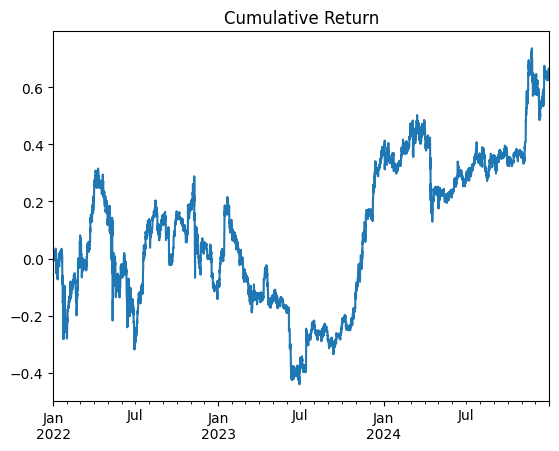

In [26]:
positions = (df_tweets['alt_count'] > df_tweets['alt_count'].rolling(24).mean()).shift(1).fillna(0).astype(int)
strategy_rets = positions.values.reshape(-1,1) * ret[['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']]
strategy_rets.mean(axis=1).cumsum().plot(title='Cumulative Return')

<Axes: title={'center': 'Momentum Cumulative Return'}>

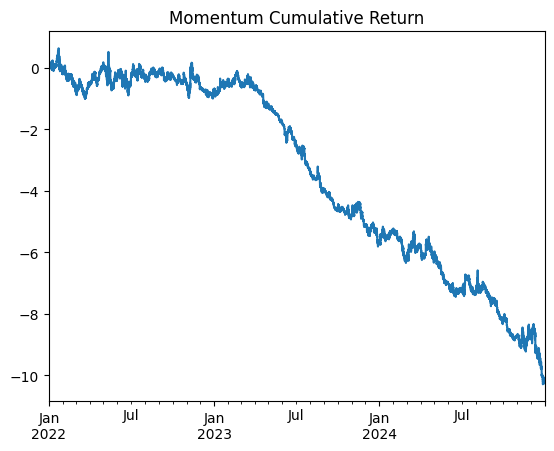

In [142]:
import numpy as np
positions = ret[['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']].shift(1).apply(np.sign)
strategy_rets_momentum = positions * ret[['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']]
strategy_rets_momentum.sum(axis=1).cumsum().plot(title='Momentum Cumulative Return')

# Next Strat - simple reversal
ADA and BNB exhibit more reversal

<Axes: title={'center': 'Reversal Cumulative Return'}>

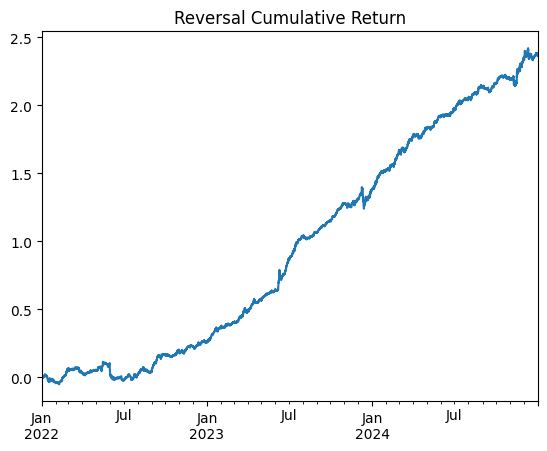

In [2]:
# positions_reversal = ret[['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']].shift(1).apply(np.sign) * -1
positions_reversal = ret[['ADAUSDT','BNBUSDT']].shift(1).apply(np.sign) * -1
positions_reversal = positions_reversal.subtract(positions_reversal.mean(axis=1), axis=0)
positions_reversal = positions_reversal.divide(positions_reversal.abs().sum(axis=1), axis=0)
# strategy_rets_reversal = positions_reversal * ret[['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']]
strategy_rets_reversal = positions_reversal * ret[['ADAUSDT','BNBUSDT']]
strategy_rets_reversal.sum(axis=1).cumsum().plot(title='Reversal Cumulative Return')

In [8]:
positions.head()

,ADAUSDT,SOLUSDT,XRPUSDT,BNBUSDT
2022-01-01 00:00:00,NaN,NaN,NaN,NaN
2022-01-01 01:00:00,NaN,NaN,NaN,NaN
2022-01-01 02:00:00,1.0,1.0,NaN,1.0
2022-01-01 03:00:00,1.0,-1.0,NaN,-1.0
2022-01-01 04:00:00,1.0,1.0,NaN,-1.0


In [133]:
strategy_rets_reversal.mean()/strategy_rets_reversal.std()*(365*24)**0.5

ADAUSDT    3.760750
BNBUSDT    4.139144
dtype: float64

In [135]:
# Regress strategy returns against BTC as market factor
import statsmodels.api as sm

market = ret['BTCUSDT']
strategy = strategy_rets_reversal.mean(axis=1)

# Add constant for alpha
X = sm.add_constant(market)
model = sm.OLS(strategy, X, missing='drop').fit()
print(model.summary())

# Key metrics
print(f'\nAlpha (annual): {model.params["const"] * 24 * 365:.2%}')
print(f'Beta:           {model.params["BTCUSDT"]:.2f}')
print(f'R-squared:      {model.rsquared:.2f}')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     3.815
Date:                Mon, 30 Mar 2026   Prob (F-statistic):             0.0508
Time:                        18:34:01   Log-Likelihood:                 38718.
No. Observations:                7775   AIC:                        -7.743e+04
Df Residuals:                    7773   BIC:                        -7.742e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002   1.89e-05      8.068      0.0

In [136]:
ret['BTCUSDT'].corr(strategy_rets_reversal.mean(axis=1)) # not correlated with BTC

np.float64(0.022149358754889804)

# Next Strat

In [121]:
# Signal: tweet count z-score
window = 3
tweet_zscore = (df_tweets['alt_count'] - df_tweets['alt_count'].rolling(window).mean()) / df_tweets['alt_count'].rolling(window).std()

# Position: long when tweets spike, flat otherwise
positions = tweet_zscore.shift(1).apply(lambda x: 1 if x > 1 else (-1 if x < -1 else 0))
positions = positions.fillna(0)

# Apply to alt coins
tickers = ['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']
strategy_rets = positions.values.reshape(-1,1) * ret[tickers]

# Backtest metrics
cum_rets = strategy_rets.sum(axis=1).cumsum()
sharpe = strategy_rets.sum(axis=1).mean() / strategy_rets.sum(axis=1).std() * np.sqrt(24*365)
total_ret = cum_rets.iloc[-1]
max_dd = (cum_rets - cum_rets.cummax()).min()

print(f'Total Return: {total_ret:.2%}')
print(f'Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2%}')
print(f'Hit Rate:     {(strategy_rets.mean(axis=1) > 0).mean():.2%}')

cum_rets.plot(title='Tweet Z-Score Strategy Cumulative Return')

ValueError: Unable to coerce to DataFrame, shape must be (6576, 4): given (26304, 1)

In [36]:
# Regress strategy returns against BTC as market factor
import statsmodels.api as sm

market = ret['BTCUSDT']
strategy = strategy_rets.sum(axis=1)

# Add constant for alpha
X = sm.add_constant(market)
model = sm.OLS(strategy, X, missing='drop').fit()
print(model.summary())

# Key metrics
print(f'\nAlpha (annual): {model.params["const"] * 24 * 365:.2%}')
print(f'Beta:           {model.params["BTCUSDT"]:.2f}')
print(f'R-squared:      {model.rsquared:.2f}')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     38.39
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           5.87e-10
Time:                        16:46:42   Log-Likelihood:                 69675.
No. Observations:               26303   AIC:                        -1.393e+05
Df Residuals:                   26301   BIC:                        -1.393e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      1.113      0.2

In [37]:
ret['BTCUSDT'].corr(strategy_rets.mean(axis=1)) # not correlated with BTC

np.float64(0.03631216685999614)

# Strat - long/short alt coins based on direction of BTC and ETH, and also depending on how many alt coin tweets 

Total Return: 99.81%
Sharpe Ratio: 1.70
Max Drawdown: -10.79%
Hit Rate:     3.86%


<Axes: title={'center': 'Alt Rotation Strategy Cumulative Return'}>

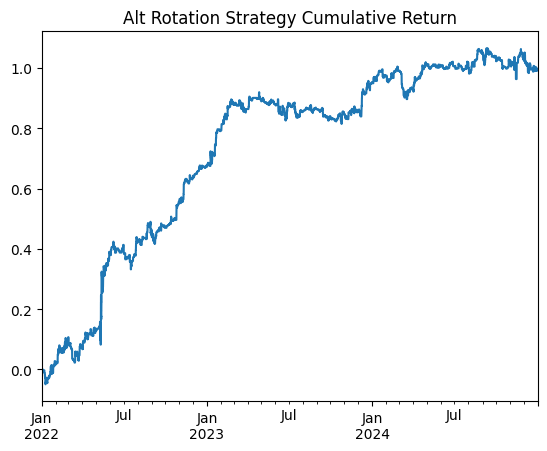

In [50]:
# BTC/ETH as market sentiment indicator for alts
window = 3

# Z-score all three tweet series
# btc_z = (df_tweets['btc_count'] - df_tweets['btc_count'].rolling(window).mean()) / df_tweets['btc_count'].rolling(window).std()
# eth_z = (df_tweets['eth_count'] - df_tweets['eth_count'].rolling(window).mean()) / df_tweets['eth_count'].rolling(window).std()
# alt_z = (df_tweets['alt_count'] - df_tweets['alt_count'].rolling(window).mean()) / df_tweets['alt_count'].rolling(window).std()


span=4
btc_z = (df_tweets['btc_count'] - df_tweets['btc_count'].ewm(span=span).mean()) / df_tweets['btc_count'].ewm(span=span).std()
eth_z = (df_tweets['eth_count'] - df_tweets['eth_count'].ewm(span=span).mean()) / df_tweets['eth_count'].ewm(span=span).std()
alt_z = (df_tweets['alt_count'] - df_tweets['alt_count'].ewm(span=span).mean()) / df_tweets['alt_count'].ewm(span=span).std()


# Signal: alts are getting attention RELATIVE to btc/eth
# If alt_z is high but btc/eth_z is low -> alts are rotating in
relative_signal = (alt_z - (btc_z + eth_z) / 2)

# Confirm with btc/eth momentum — only trade alts when big coins are trending up
btc_ret = ret['BTCUSDT'].rolling(window).mean()
eth_ret = ret['ETHUSDT'].rolling(window).mean()
market_trending_up = ((btc_ret > 0) & (eth_ret > 0)).astype(int)

# Combined signal
signal = relative_signal.shift(1) * market_trending_up.shift(1)
thresh = 1
positions = signal.apply(lambda x: 1 if x > thresh else (-1 if x < -thresh else 0)).fillna(0)
# positions = relative_signal.clip(-2,2)

# Apply to alt coins
tickers = ['ADAUSDT','BNBUSDT']
# tickers = ['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']
strategy_rets = positions.values.reshape(-1,1) * ret[tickers]

# Backtest metrics
cum_rets = strategy_rets.mean(axis=1).cumsum()
sharpe = strategy_rets.mean(axis=1).mean() / strategy_rets.mean(axis=1).std() * np.sqrt(24*365)
total_ret = cum_rets.iloc[-1]
max_dd = (cum_rets - cum_rets.cummax()).min()

print(f'Total Return: {total_ret:.2%}')
print(f'Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2%}')
print(f'Hit Rate:     {(strategy_rets.mean(axis=1) > 0).mean():.2%}')

cum_rets.plot(title='Alt Rotation Strategy Cumulative Return')

# TODO: COMBINE WITH REVERSAL STRATEGY
# TOOD: think about dollar neutrality

In [5]:
strategy_rets

,ADAUSDT,BNBUSDT
2022-01-01 00:00:00,NaN,NaN
2022-01-01 01:00:00,-0.000000,-0.000000
2022-01-01 02:00:00,-0.000000,0.000000
2022-01-01 03:00:00,-0.000000,0.000000
2022-01-01 04:00:00,0.012008,0.006439
...,...,...
2024-12-31 19:00:00,0.000000,-0.000000
2024-12-31 20:00:00,-0.000000,-0.000000
2024-12-31 21:00:00,0.000000,0.000000
2024-12-31 22:00:00,-0.000000,-0.000000


In [56]:
k = 0.9
positions_mixture = (k*positions_reversal).add((1-k)*positions, axis=0)
positions_mixture = positions_mixture.subtract(positions_mixture.mean(axis=1), axis=0)
positions_mixture = positions_mixture.divide(positions_mixture.abs().sum(axis=1), axis=0)

<Axes: title={'center': 'Mixture Strategy Cumulative Return'}>

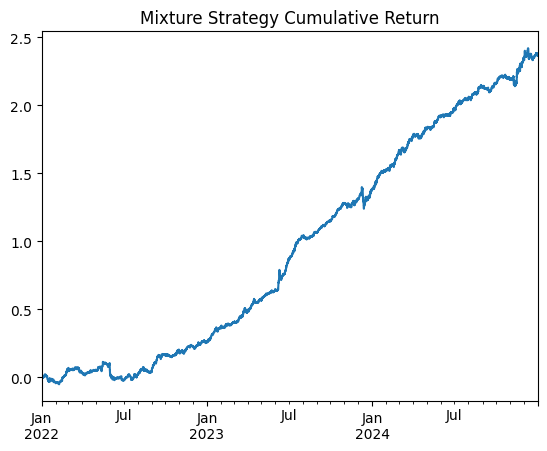

In [57]:
strategy_rets_mixture = positions_mixture * ret[['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']]
strategy_rets_mixture = positions_mixture * ret[['ADAUSDT','BNBUSDT']]
strategy_rets_mixture.sum(axis=1).cumsum().plot(title='Mixture Strategy Cumulative Return')

In [58]:
strategy_rets_mixture.mean(axis=1).mean()/strategy_rets_mixture.mean(axis=1).std()*np.sqrt(365*24)

np.float64(8.558434546993043)

In [80]:
positions_reversal

,ADAUSDT,SOLUSDT,XRPUSDT,BNBUSDT
2022-01-01 00:00:00,NaN,NaN,NaN,NaN
2022-01-01 01:00:00,NaN,NaN,NaN,NaN
2022-01-01 02:00:00,1.0,1.0,NaN,1.0
2022-01-01 03:00:00,1.0,-1.0,NaN,-1.0
2022-01-01 04:00:00,1.0,1.0,NaN,-1.0
...,...,...,...,...
2024-12-31 19:00:00,1.0,1.0,-1.0,1.0
2024-12-31 20:00:00,-0.0,1.0,-1.0,1.0
2024-12-31 21:00:00,1.0,-1.0,-1.0,1.0
2024-12-31 22:00:00,-1.0,1.0,1.0,-1.0


<Axes: >

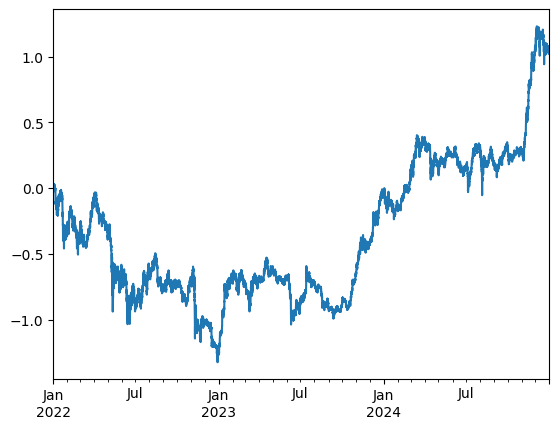

In [67]:
ret[['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']].mean(axis=1).cumsum().plot()

### Factoring in t-costs

In [31]:
to = (positions_mixture.fillna(0) - positions_mixture.fillna(0).shift()).abs().sum(1)

<Axes: >

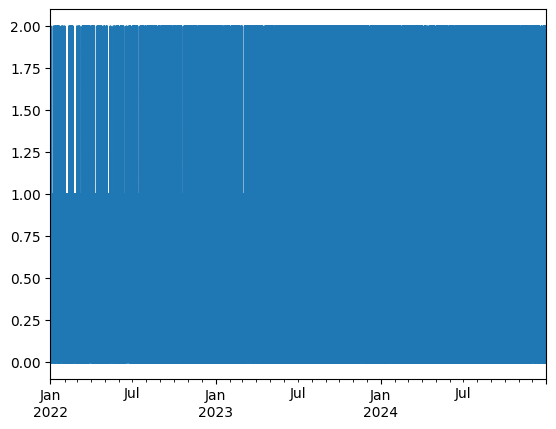

In [32]:
to.plot()

In [33]:
to.mean()

np.float64(0.513610097323601)

In [37]:
gross_ret = strategy_rets_mixture.sum(1)

In [47]:
tcost_bps = 20 # (estimate of avg commissions + avg slippage)
net_ret = gross_ret.subtract(to*tcost_bps*1e-4, fill_value=0)
net_ret

2022-01-01 00:00:00    0.000000
2022-01-01 01:00:00    0.000000
2022-01-01 02:00:00    0.000000
2022-01-01 03:00:00   -0.002711
2022-01-01 04:00:00   -0.002784
                         ...   
2024-12-31 19:00:00    0.000000
2024-12-31 20:00:00   -0.003157
2024-12-31 21:00:00   -0.002000
2024-12-31 22:00:00    0.000000
2024-12-31 23:00:00    0.000000
Freq: h, Length: 26304, dtype: float64

In [59]:
# sharpe is now -40 :(
net_ret.mean() / net_ret.std() * np.sqrt(24*365)

np.float64(-41.12485783338223)

# Next Strat - combining previous strat with buying BTC depending on its rolling z-score

Total Return: 73.86%
Sharpe Ratio: 1.24
Max Drawdown: -19.02%
Hit Rate:     24.61%


<Axes: title={'center': 'Combined Strategy Cumulative Return'}>

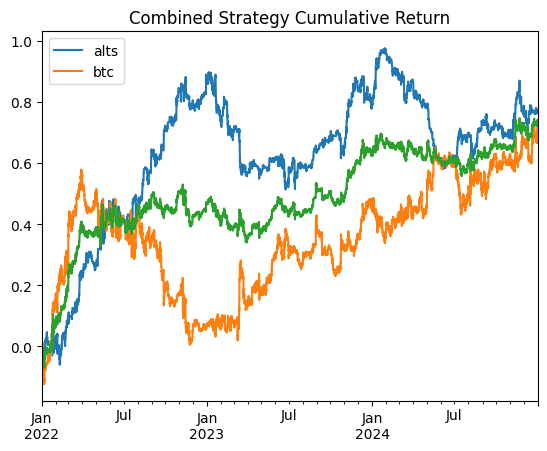

In [38]:
# Z-score tweet series
window = 24
btc_z = (df_tweets['btc_count'] - df_tweets['btc_count'].rolling(window).mean()) / df_tweets['btc_count'].rolling(window).std()
eth_z = (df_tweets['eth_count'] - df_tweets['eth_count'].rolling(window).mean()) / df_tweets['eth_count'].rolling(window).std()
alt_z = (df_tweets['alt_count'] - df_tweets['alt_count'].rolling(window).mean()) / df_tweets['alt_count'].rolling(window).std()

# Relative attention signal for alts
relative_signal = alt_z - (btc_z + eth_z) / 2

# BTC specific signal — trade BTC directly on its own tweet z-score
btc_signal = btc_z - (eth_z + alt_z) / 2  # BTC getting attention relative to others

# Market regime filter
btc_ret = ret['BTCUSDT'].rolling(window).mean()
eth_ret = ret['ETHUSDT'].rolling(window).mean()
market_trending_up = ((btc_ret > 0) & (eth_ret > 0)).astype(int)

# Alt positions
alt_signal = relative_signal.shift(1) * market_trending_up.shift(1)
alt_positions = alt_signal.apply(lambda x: 1 if x > 1 else (-1 if x < -1 else 0)).fillna(0)

# BTC position — don't apply regime filter since BTC IS the regime
btc_position = btc_signal.shift(1).apply(lambda x: 1 if x > 1 else (-1 if x < -1 else 0)).fillna(0)

# Apply to tickers
alt_tickers = ['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']
alt_rets = ret[alt_tickers].multiply(alt_positions, axis=0)
btc_rets = ret['BTCUSDT'] * btc_position

# Combine — equal weight BTC vs alt basket
strategy_rets = pd.concat([alt_rets.mean(axis=1), btc_rets], axis=1)
strategy_rets.columns = ['alts', 'btc']
combined = strategy_rets.mean(axis=1)

# Backtest metrics
cum_rets = combined.cumsum()
sharpe = combined.mean() / combined.std() * np.sqrt(24*365)
total_ret = cum_rets.iloc[-1]
max_dd = (cum_rets - cum_rets.cummax()).min()

print(f'Total Return: {total_ret:.2%}')
print(f'Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2%}')
print(f'Hit Rate:     {(combined > 0).mean():.2%}')

# Plot both legs separately and combined
strategy_rets.cumsum().plot(title='BTC vs Alt Legs')
combined.cumsum().plot(title='Combined Strategy Cumulative Return')

In [41]:
# Regress strategy returns against BTC as market factor
import statsmodels.api as sm

market = ret['BTCUSDT']
strategy = combined

# Add constant for alpha
X = sm.add_constant(market)
model = sm.OLS(strategy, X, missing='drop').fit()
print(model.summary())

# Key metrics
print(f'\nAlpha (annual): {model.params["const"] * 24 * 365:.2%}')
print(f'Beta:           {model.params["BTCUSDT"]:.2f}')
print(f'R-squared:      {model.rsquared:.2f}')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     240.8
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           4.53e-54
Time:                        16:48:05   Log-Likelihood:             1.2471e+05
No. Observations:               26303   AIC:                        -2.494e+05
Df Residuals:                   26301   BIC:                        -2.494e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.657e-05    1.3e-05      2.040      0.0

# Next Strat

Total Return: 4.16%
Sharpe Ratio: 0.03
Max Drawdown: -95.18%
Hit Rate:     49.88%


<Axes: title={'center': 'Cross-Sectional Laggard Strategy Cumulative Return'}>

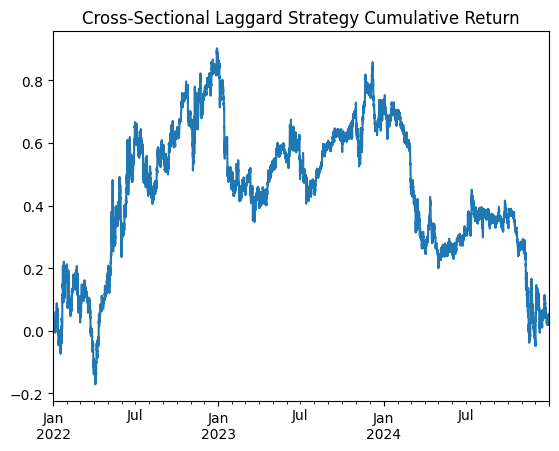

In [51]:
# Cross-sectional: rank alts by their own tweet-implied momentum vs actual return
# Idea: if a coin's return has LAGGED its tweet attention, it may catch up

window = 24
tickers = ['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']

# Cumulative tweet attention per coin (use alt_z as proxy for all)
# Ideally you'd have per-coin tweets but we can use ret to rank within alts
tweet_momentum = alt_z.rolling(window).mean()  # sustained attention

# Rank coins by recent return (cross-sectional)
ret_rank = ret[tickers].rolling(window).mean().rank(axis=1, ascending=True)

# Tweet-implied demand rank (same signal broadcast to all alts for now)
# Subtract return rank: high tweet attention + low return rank = laggard, go long
laggard_signal = -ret_rank.multiply(tweet_momentum.shift(1).values.reshape(-1,1))

# Normalize positions to be dollar neutral (long top 2, short bottom 2)
def rank_to_position(row):
    ranked = row.rank()
    n = len(ranked)
    positions = ranked - (n + 1) / 2  # center around 0
    return positions / positions.abs().sum()  # normalize

positions = laggard_signal.apply(rank_to_position, axis=1).fillna(0)

# Backtest
strategy_rets = (positions * ret[tickers])
cum_rets = strategy_rets.sum(axis=1).cumsum()
sharpe = strategy_rets.sum(axis=1).mean() / strategy_rets.sum(axis=1).std() * np.sqrt(24*365)
total_ret = cum_rets.iloc[-1]
max_dd = (cum_rets - cum_rets.cummax()).min()

print(f'Total Return: {total_ret:.2%}')
print(f'Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2%}')
print(f'Hit Rate:     {(strategy_rets.sum(axis=1) > 0).mean():.2%}')

cum_rets.plot(title='Cross-Sectional Laggard Strategy Cumulative Return')

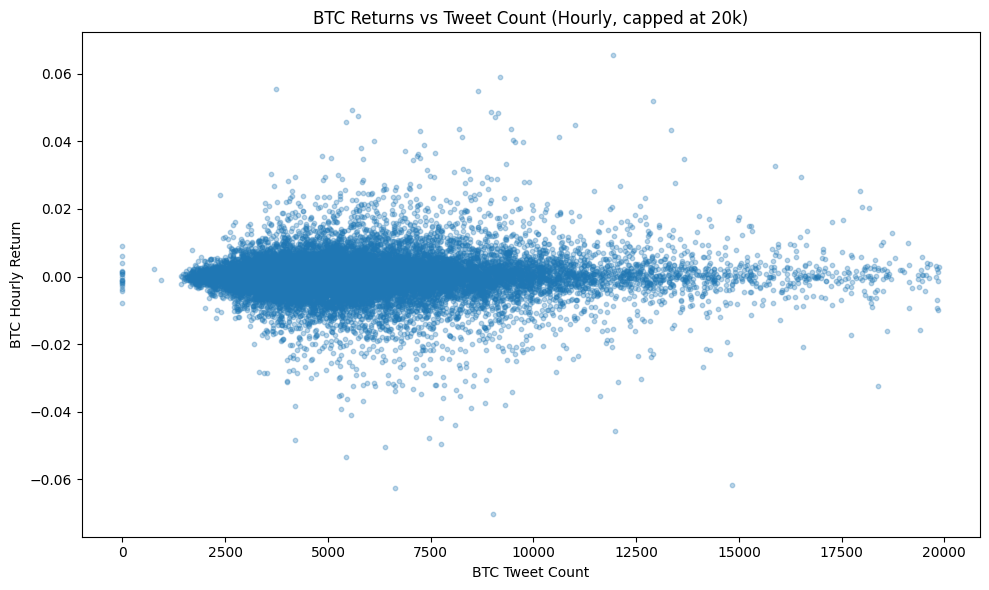

In [ ]:
import matplotlib.pyplot as plt


combined_counts_returns_btc = pd.concat([df_tweets['btc_count'], ret['BTCUSDT']], axis=1).dropna()
combined_counts_returns_btc = combined_counts_returns_btc[combined_counts_returns_btc['btc_count'] < 20000]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(combined_counts_returns_btc['btc_count'], combined_counts_returns_btc['BTCUSDT'], alpha=0.3, s=10)

ax.set_xlabel('BTC Tweet Count')
ax.set_ylabel('BTC Hourly Return')
ax.set_title('BTC Returns vs Tweet Count (Hourly, capped at 20k)')

plt.tight_layout()
plt.show()

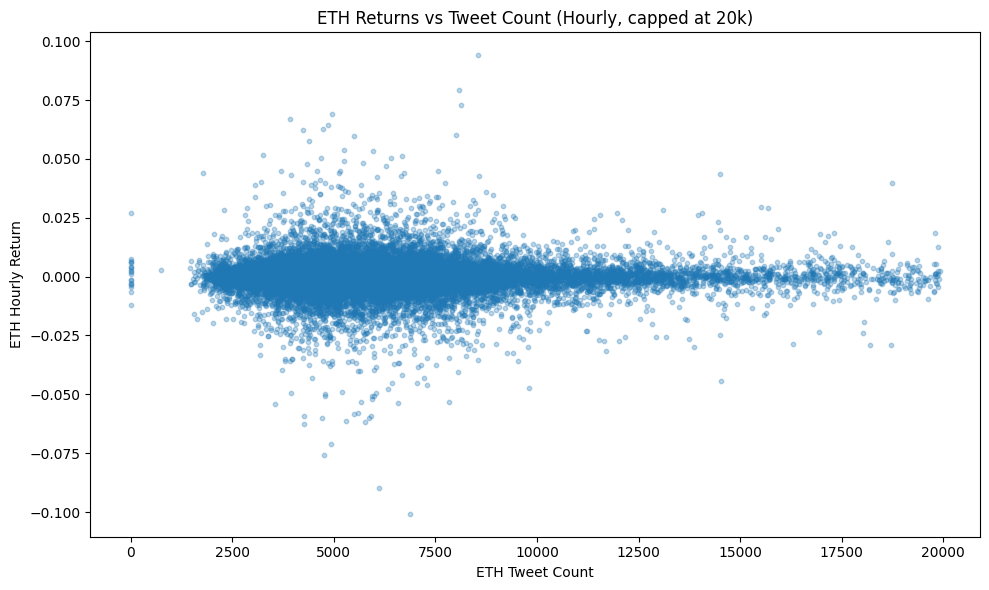

In [51]:
import matplotlib.pyplot as plt


combined_counts_returns_eth = pd.concat([df_tweets['eth_count'], ret['ETHUSDT']], axis=1).dropna()
combined_counts_returns_eth = combined_counts_returns_eth[combined_counts_returns_eth['eth_count'] < 20000]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(combined_counts_returns_eth['eth_count'], combined_counts_returns_eth['ETHUSDT'], alpha=0.3, s=10)

ax.set_xlabel('ETH Tweet Count')
ax.set_ylabel('ETH Hourly Return')
ax.set_title('ETH Returns vs Tweet Count (Hourly, capped at 20k)')

plt.tight_layout()
plt.show()

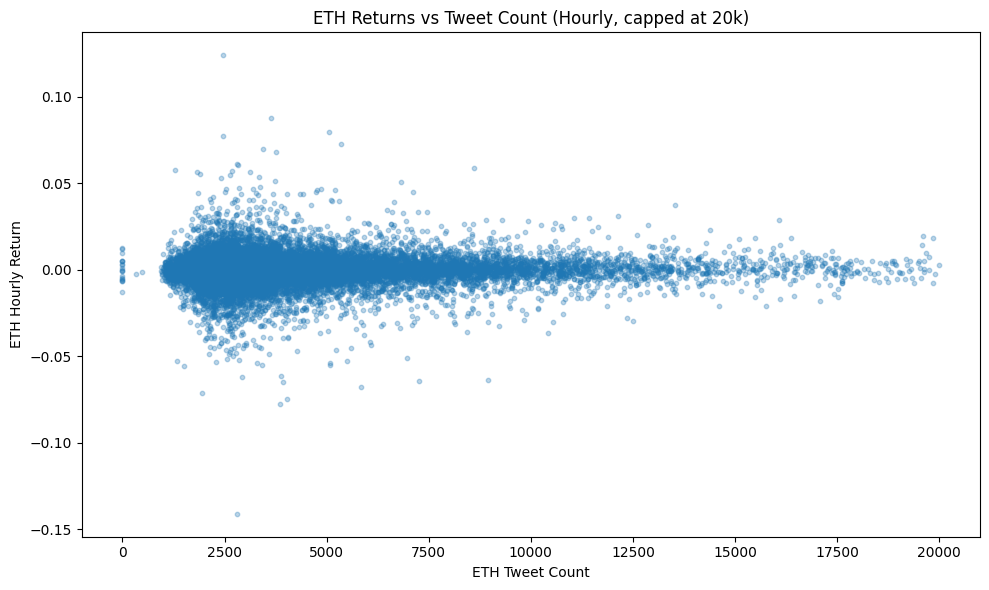

In [60]:
import matplotlib.pyplot as plt


combined_counts_returns_alt = pd.concat([df_tweets['alt_count'], ret[['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']].mean(axis=1)], axis=1).dropna()
combined_counts_returns_alt = combined_counts_returns_alt[combined_counts_returns_alt['alt_count'] < 20000]

combined_counts_returns_alt.columns = ['alt_count', 'alt_returns']

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(combined_counts_returns_alt['alt_count'], combined_counts_returns_alt['alt_returns'], alpha=0.3, s=10)

ax.set_xlabel('ETH Tweet Count')
ax.set_ylabel('ETH Hourly Return')
ax.set_title('ETH Returns vs Tweet Count (Hourly, capped at 20k)')

plt.tight_layout()
plt.show()

# Next Strat (rebalancing every 4 hours instead of 1 hour)

In [92]:
hours = 4
ret_4h = px.xs('close', axis=1, level=1).astype(float).pct_change(periods=hours)

/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_3252/637542163.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_4h = px.xs('close', axis=1, level=1).astype(float).pct_change(periods=hours)


In [93]:
ret.head()

,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,ADAUSDT,BNBUSDT
2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:00:00,0.002362,0.000965,-0.000244,NaN,-0.000925,-0.000425
2022-01-01 02:00:00,-0.000093,0.001630,0.002401,NaN,-0.001747,0.001075
2022-01-01 03:00:00,0.000985,-0.001370,-0.000292,NaN,-0.000830,0.000593
2022-01-01 04:00:00,-0.001968,-0.004987,-0.007844,NaN,-0.012008,-0.006439


In [94]:
ret_4h.head()

,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,ADAUSDT,BNBUSDT
2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 04:00:00,0.001281,-0.00377,-0.005996,NaN,-0.015463,-0.005204


NameError: name 'strategy_rets_reversal' is not defined

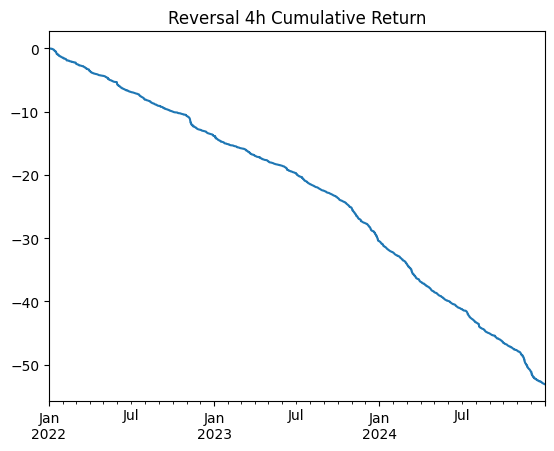

In [95]:
positions_reversal_4h = ret_4h[['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']].shift(1).apply(np.sign) * -1
# positions_reversal_4h = ret[['ADAUSDT','BNBUSDT']].shift(1).apply(np.sign) * -1
positions_reversal_4h = positions_reversal_4h.subtract(positions_reversal_4h.mean(axis=1), axis=0)
positions_reversal_4h = positions_reversal_4h.divide(positions_reversal_4h.abs().sum(axis=1), axis=0)
strategy_rets_reversal_4h = positions_reversal_4h * ret_4h[['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']]
# strategy_rets_reversal_4h = positions_reversal_4h * ret_4h[['ADAUSDT','BNBUSDT']]
strategy_rets_reversal_4h.sum(axis=1).cumsum().plot(title='Reversal 4h Cumulative Return')
strategy_rets_reversal_4h.mean()/strategy_rets_reversal.std()*(365*(24/hours))**0.5

# Next Strat (accumulating 4 hour twitter data instead of using hourly)

Total Return: 299.13%
Sharpe Ratio: 1.30
Max Drawdown: -73.63%
Hit Rate:     4.62%


/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_73022/2705449607.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_h = px.xs('close', axis=1, level=1).astype(float).resample(freq_str).last().pct_change(periods=1)


<Axes: title={'center': 'Alt Rotation Strategy Cumulative Return'}>

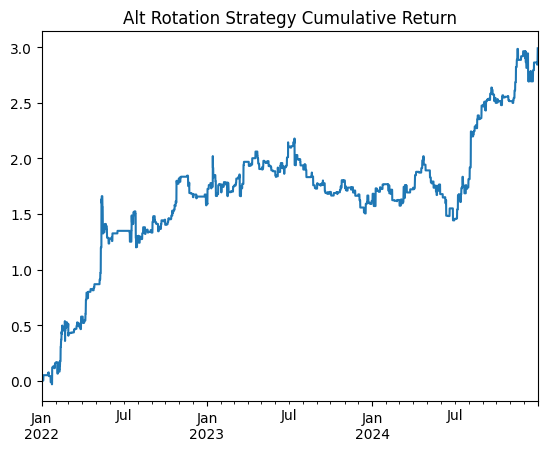

In [122]:
num_hours = 4
freq_str = str(num_hours)+'h'

df_tweets_h = df_tweets.resample(freq_str).sum()
ret_h = px.xs('close', axis=1, level=1).astype(float).resample(freq_str).last().pct_change(periods=1)

# BTC/ETH as market sentiment indicator for alts
window = 3

# Z-score all three tweet series
btc_z = (df_tweets_h['btc_count'] - df_tweets_h['btc_count'].rolling(window).mean()) / df_tweets_h['btc_count'].rolling(window).std()
eth_z = (df_tweets_h['eth_count'] - df_tweets_h['eth_count'].rolling(window).mean()) / df_tweets_h['eth_count'].rolling(window).std()
alt_z = (df_tweets_h['alt_count'] - df_tweets_h['alt_count'].rolling(window).mean()) / df_tweets_h['alt_count'].rolling(window).std()


# Signal: alts are getting attention RELATIVE to btc/eth
# If alt_z is high but btc/eth_z is low -> alts are rotating in
relative_signal = (alt_z - (0.5*btc_z + 0.5*eth_z))

# Confirm with btc/eth momentum — only trade alts when big coins are trending up
btc_ret = ret_h['BTCUSDT'].rolling(window).mean()
eth_ret = ret_h['ETHUSDT'].rolling(window).mean()
market_trending_up = ((btc_ret > 0) & (eth_ret > 0)).astype(int)
high_vol = (ret_h['BTCUSDT']>ret_h['BTCUSDT'].rolling(5).median()).astype(int) # further regime filtering here

# Combined signal
signal_1 = relative_signal.shift(1) * market_trending_up.shift(1) * high_vol.shift(1)
thresh = 1
positions = signal_1.apply(lambda x: 1 if x > thresh else (-1 if x < -thresh else 0)).fillna(0)
# positions = relative_signal.clip(-2,2)

# Apply to alt coins
# tickers = ['ADAUSDT','BNBUSDT']
tickers = ['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']
strategy_rets_1 = positions.values.reshape(-1,1) * ret_h[tickers]

# Backtest metrics
cum_rets = strategy_rets_1.sum(axis=1).cumsum()
sharpe = strategy_rets_1.mean(axis=1).mean() / strategy_rets_1.mean(axis=1).std() * np.sqrt((24/num_hours)*365)
total_ret = cum_rets.iloc[-1]
max_dd = (cum_rets - cum_rets.cummax()).min()

print(f'Total Return: {total_ret:.2%}')
print(f'Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2%}')
print(f'Hit Rate:     {(strategy_rets_1.mean(axis=1) > 0).mean():.2%}')

cum_rets.plot(title='Alt Rotation Strategy Cumulative Return')

# Next Strat: Taker Imabalance (varying time frames)

Total Return: 66.98%
Sharpe Ratio: 0.62
Max Drawdown: -36.13%
Hit Rate:     50.50%


/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/924304364.py:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = px.xs('close', axis=1, level=1).resample(freq_str).last().pct_change(1)[tickers]


<Axes: title={'center': 'Taker Imbalance'}>

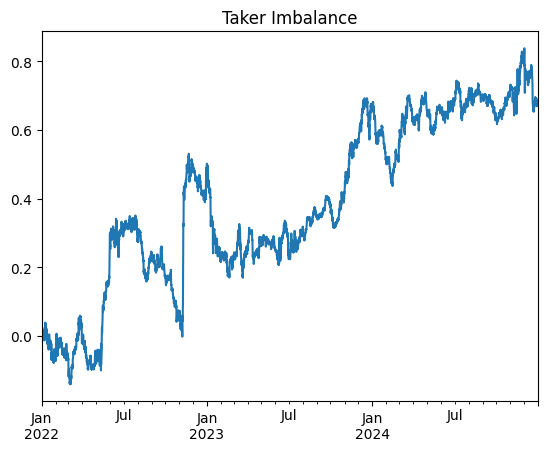

In [189]:
num_hours = 4
freq_str = str(num_hours) + 'h'
tickers = ['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']

volume = px.xs('volume', axis=1, level=1).resample(freq_str).sum()[tickers]
taker_quote_volume = px.xs('taker_quote_volume', axis=1, level=1).resample(freq_str).sum()[tickers]
quote_volume = px.xs('quote_volume', axis=1, level=1).resample(freq_str).sum()[tickers]

buy_vol = taker_quote_volume
sell_vol = quote_volume - taker_quote_volume
signal_2 = (buy_vol - sell_vol)/quote_volume # -1 indicates aggressive selling, +1 indicates aggressive buying
signal_2 = signal_2.shift(1)

ret = px.xs('close', axis=1, level=1).resample(freq_str).last().pct_change(1)[tickers]

signal_2 = signal_2.rank(axis=1)
signal_2 = signal_2.subtract(signal_2.mean(axis=1), axis=0)
signal_2 = signal_2.divide(signal_2.abs().sum(axis=1), axis=0)
weights = signal_2

strategy_rets_2 = weights*ret

# Backtest metrics
cum_rets = strategy_rets_2.sum(axis=1).cumsum()
sharpe = strategy_rets_2.mean(axis=1).mean() / strategy_rets_2.mean(axis=1).std() * np.sqrt((24/num_hours)*365)
total_ret = cum_rets.iloc[-1]
max_dd = (cum_rets - cum_rets.cummax()).min()

print(f'Total Return: {total_ret:.2%}')
print(f'Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2%}')
print(f'Hit Rate:     {(strategy_rets_2.mean(axis=1) > 0).mean():.2%}')

cum_rets.plot(title='Taker Imbalance')

In [124]:
signal_2.corrwith(signal_1)

ADAUSDT   -0.008440
SOLUSDT    0.003879
XRPUSDT   -0.008277
BNBUSDT    0.007662
dtype: float64

# Combining the previous two strategies

Total Return: 183.06%
Sharpe Ratio: 1.49
Max Drawdown: -29.99%
Hit Rate:     50.81%


<Axes: title={'center': 'Combined Strat'}>

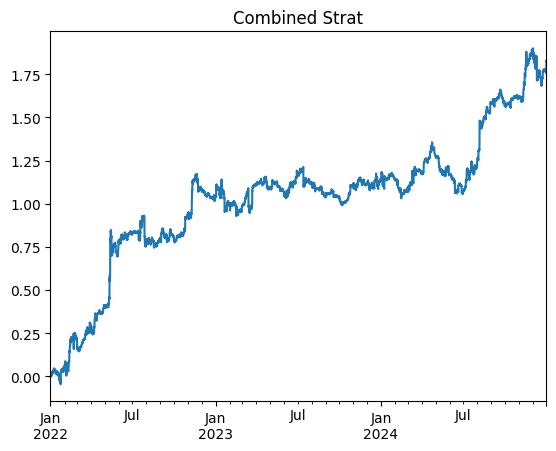

In [126]:
w=0.5
strategy_rets_combined = w * strategy_rets_1.sum(axis=1) + (1-w) * strategy_rets_2.sum(axis=1)

# Backtest metrics
cum_rets = strategy_rets_combined.cumsum()
sharpe = strategy_rets_combined.mean() / strategy_rets_combined.std() * np.sqrt((24/num_hours)*365)
total_ret = cum_rets.iloc[-1]
max_dd = (cum_rets - cum_rets.cummax()).min()

print(f'Total Return: {total_ret:.2%}')
print(f'Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2%}')
print(f'Hit Rate:     {(strategy_rets_combined > 0).mean():.2%}')

cum_rets.plot(title='Combined Strat')

In [127]:
strategy_rets_combined

2022-01-01 00:00:00    0.000000
2022-01-01 04:00:00   -0.002000
2022-01-01 08:00:00   -0.001947
2022-01-01 12:00:00   -0.000369
2022-01-01 16:00:00    0.003140
                         ...   
2024-12-31 04:00:00   -0.000662
2024-12-31 08:00:00   -0.002572
2024-12-31 12:00:00    0.032618
2024-12-31 16:00:00    0.036654
2024-12-31 20:00:00   -0.002209
Freq: 4h, Length: 6576, dtype: float64

# Using signal 2 as alpha, and signal 1 as regime filter (pretty bad)

Total Return: 15.82%
Sharpe Ratio: 0.36
Max Drawdown: -30.30%
Hit Rate:     10.28%


<Axes: title={'center': 'Signal 1 as alpha, signal 2 as regime filter'}>

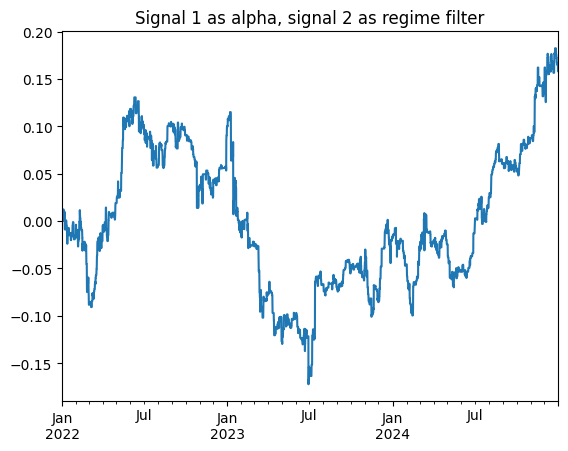

In [129]:
weights = signal_2.copy()
weights = weights.multiply(market_trending_up.shift(1), axis=0)
weights = weights.multiply(high_vol.shift(1), axis=0)

strategy_rets_other = (weights * ret).sum(axis=1)

# Backtest metrics
cum_rets = strategy_rets_other.cumsum()
sharpe = strategy_rets_other.mean() / strategy_rets_other.std() * np.sqrt((24/num_hours)*365)
total_ret = cum_rets.iloc[-1]
max_dd = (cum_rets - cum_rets.cummax()).min()

print(f'Total Return: {total_ret:.2%}')
print(f'Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2%}')
print(f'Hit Rate:     {(strategy_rets_other > 0).mean():.2%}')

cum_rets.plot(title='Signal 1 as alpha, signal 2 as regime filter')

# Reversal at different time periods

Total Return: 68.17%
Sharpe Ratio: 1.07
Max Drawdown: -29.22%
Hit Rate:     23.60%


<Axes: title={'center': 'Reversal'}>

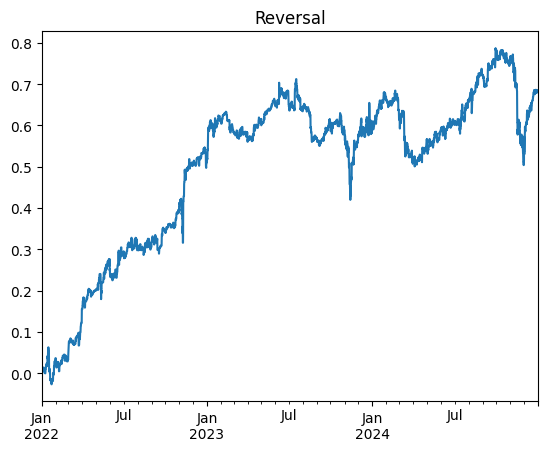

In [130]:
positions_reversal = ret[['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']].shift(1).apply(np.sign) * -1
positions_reversal = positions_reversal.subtract(positions_reversal.mean(axis=1), axis=0)
positions_reversal = positions_reversal.divide(positions_reversal.abs().sum(axis=1), axis=0)
strategy_rets_reversal = (positions_reversal * ret[['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']]).sum(axis=1)

# Backtest metrics
cum_rets = strategy_rets_reversal.cumsum()
sharpe = strategy_rets_reversal.mean() / strategy_rets_reversal.std() * np.sqrt((24/num_hours)*365)
total_ret = cum_rets.iloc[-1]
max_dd = (cum_rets - cum_rets.cummax()).min()

print(f'Total Return: {total_ret:.2%}')
print(f'Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2%}')
print(f'Hit Rate:     {(strategy_rets_reversal > 0).mean():.2%}')

cum_rets.plot(title='Reversal')

# Next strat: combining reversal + twitter + taker imbalance

Total Return: 14275.87%
Sharpe Ratio: 1.88
Max Drawdown: -1396.40%
Hit Rate:     52.27%


<Axes: title={'center': 'Combined Strat 2'}>

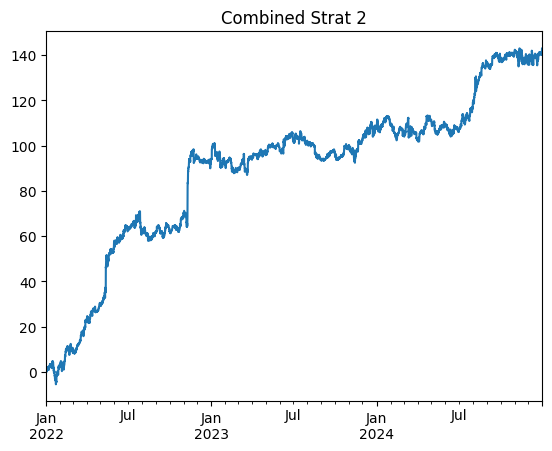

In [146]:
w1, w2 = 0.33, 0.33

r1 = strategy_rets_1.sum(axis=1)
r2 = strategy_rets_2.sum(axis=1)
r3 = strategy_rets_reversal  # if already a single series

vol1 = r1.std()
vol2 = r2.std()
vol3 = r3.std()

r1_scaled = r1 / vol1
r2_scaled = r2 / vol2
r3_scaled = r3 / vol3

strategy_rets_combined_2 = w1*r1_scaled + w2*r2_scaled + (1-w1-w2)*r3_scaled

# Backtest metrics
cum_rets = strategy_rets_combined_2.cumsum()
sharpe = strategy_rets_combined_2.mean() / strategy_rets_combined_2.std() * np.sqrt((24/num_hours)*365)
total_ret = cum_rets.iloc[-1]
max_dd = (cum_rets - cum_rets.cummax()).min()

print(f'Total Return: {total_ret:.2%}')
print(f'Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2%}')
print(f'Hit Rate:     {(strategy_rets_combined_2 > 0).mean():.2%}')

cum_rets.plot(title='Combined Strat 2')

# Next Strat: Volatility-based reversal

In [45]:
num_hours = 4
freq_str = str(num_hours)+'h'

df_tweets_h = df_tweets.resample(freq_str).sum()
ret_h = px.xs('close', axis=1, level=1).astype(float).resample(freq_str).last().pct_change(periods=1)

realized_vol = ret_h.rolling(6).std() # one day

/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/3285155018.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_h = px.xs('close', axis=1, level=1).astype(float).resample(freq_str).last().pct_change(periods=1)


In [46]:
recent_ret = ret.rolling(6).sum()
vol_z = (realized_vol - realized_vol.rolling(42).mean())/realized_vol.rolling(42).std()
signal=-(recent_ret*vol_z)

In [49]:
from scipy.stats import norm
def rank_normal(df):
    r = df.rank(axis=1)
    scaled = r.divide(r.shape[1]+1)
    return scaled.apply(norm.ppf)
    

signal = rank_normal(signal)
signal = signal.subtract(signal.mean(axis=1), axis=0)
signal = signal.divide(signal.abs().sum(axis=1), axis=0)
weights = signal.shift(1)

strat_ret = (weights*ret).sum(axis=1)
strat_ret.mean()/strat_ret.std()*np.sqrt(6*365)

np.float64(-0.9020074824251487)

# Next Strat - idek what's going on

In [52]:
# ── macro stress indicators ───────────────────────────────────────────────────

# 1. realised volatility (you already have this — use BTC as market proxy)
realized_vol_macro = ret_h['BTCUSDT'].rolling(42).std() * np.sqrt(num_hours*365)

# 2. return dispersion (cross-sectional std of returns each bar)
dispersion = ret_h.std(axis=1).rolling(42).mean()

# 3. pairwise correlation (avg rolling corr across all pairs)
rolling_corr = ret_h.rolling(42).corr()                        # multiindex: (time, ticker) x ticker
avg_corr = rolling_corr.groupby(level=0).apply(
    lambda m: m.values[~np.eye(len(m), dtype=bool)].mean()     # off-diagonal mean
)

# 4. implied volatility — use BTCUSDT funding rate as a proxy if you don't have VIX
# or pull crypto fear & greed / BTC options IV from another source
# simplest proxy available in your data: realised vol of realised vol (vol-of-vol)
vol_of_vol = realized_vol_macro.rolling(42).std()

# ── combine into a single stress index (z-score each, average) ───────────────

def zscore(s):
    return (s - s.rolling(180).mean()) / s.rolling(180).std()

stress = pd.concat([
    zscore(realized_vol_macro).rename('rvol'),
    zscore(dispersion).rename('dispersion'),
    zscore(avg_corr).rename('corr'),
    zscore(vol_of_vol).rename('vol_of_vol'),
], axis=1).mean(axis=1)

# ── regime split ──────────────────────────────────────────────────────────────

high_stress = stress > stress.rolling(180).median()
low_stress  = ~high_stress

# ── reversal signal IC by regime ─────────────────────────────────────────────

realized_vol_cs = ret_h.rolling(42).std()
vol_z_cs = (realized_vol_cs - realized_vol_cs.rolling(180).mean()) / realized_vol_cs.rolling(180).std()
recent_ret = ret_h.rolling(4).sum()
reversal_signal = -(recent_ret * vol_z_cs)

ic_per_bar = reversal_signal.shift(1).corrwith(ret_h, axis=1)   # IC each bar

print("mean IC — high stress : ", ic_per_bar[high_stress].mean().round(4))
print("mean IC — low stress  : ", ic_per_bar[low_stress].mean().round(4))
print("t-stat difference     : ", (
    (ic_per_bar[high_stress].mean() - ic_per_bar[low_stress].mean()) /
    np.sqrt(ic_per_bar[high_stress].var()/high_stress.sum() +
            ic_per_bar[low_stress].var()/low_stress.sum())
).round(3))

# ── or look at Sharpe by regime ───────────────────────────────────────────────

signal_norm = reversal_signal.rank(axis=1)
signal_norm = signal_norm.subtract(signal_norm.mean(axis=1), axis=0)
signal_norm = signal_norm.divide(signal_norm.abs().sum(axis=1), axis=0)
weights_rev = signal_norm.shift(1)
strat_ret = (weights_rev * ret_h).sum(axis=1)

def sharpe(s): return s.mean() / s.std() * np.sqrt(num_hours*365)

print("Sharpe — high stress  : ", sharpe(strat_ret[high_stress]).round(3))
print("Sharpe — low stress   : ", sharpe(strat_ret[low_stress]).round(3))

mean IC — high stress :  0.0019
mean IC — low stress  :  -0.0113
t-stat difference     :  0.966
Sharpe — high stress  :  -0.917
Sharpe — low stress   :  0.308


In [69]:
ret_h.rolling(42).corr().groupby(level=0).apply(lambda m: m.values[~np.eye(len(m), dtype=bool)].mean())

2022-01-01 00:00:00         NaN
2022-01-01 04:00:00         NaN
2022-01-01 08:00:00         NaN
2022-01-01 12:00:00         NaN
2022-01-01 16:00:00         NaN
                         ...   
2024-12-31 04:00:00    0.800821
2024-12-31 08:00:00    0.808412
2024-12-31 12:00:00    0.802401
2024-12-31 16:00:00    0.808304
2024-12-31 20:00:00    0.806060
Length: 6576, dtype: float64

# Next Strat
Hypothesis: when BTC taker imbalance is negative but alt imbalance is positive, are alts about to outperform?
Tests BTC -> alt rotation thesis

In [231]:
num_hours = 6
freq_str = str(num_hours) + 'h'
tickers = ['ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']

ret_h = px.xs('close', axis=1, level=1).resample(freq_str).last().pct_change(1)
volume = px.xs('volume', axis=1, level=1).resample(freq_str).sum()
taker_quote_volume = px.xs('taker_quote_volume', axis=1, level=1).resample(freq_str).sum()
quote_volume = px.xs('quote_volume', axis=1, level=1).resample(freq_str).sum()

/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/1474461201.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_h = px.xs('close', axis=1, level=1).resample(freq_str).last().pct_change(1)


In [232]:
buy_volume = taker_quote_volume
sell_volume  = quote_volume - taker_quote_volume
taker_imbalance = (buy_volume - sell_volume)/quote_volume

btc_imbalance = taker_imbalance['BTCUSDT']
eth_imbalance = taker_imbalance['ETHUSDT']
alt_imbalance = taker_imbalance[['ETHUSDT', 'ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']]

btc_imbalance_neg = btc_imbalance < 0
eth_imbalance_pos = eth_imbalance > 0
alt_imbalance_pos = alt_imbalance.mean(axis=1) > 0

# alt_regime = btc_imbalance_neg & alt_imbalance_pos
alt_regime = btc_imbalance_neg & eth_imbalance_pos
filter = alt_regime.shift(1).fillna(False)

print(f'regime occurrene rate: {alt_regime.mean():.4f}')

in_regime = ret_h[filter][['ETHUSDT', 'ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']].mean(axis=1).mean()
out_regime = ret_h[~filter][['ETHUSDT', 'ADAUSDT','SOLUSDT','XRPUSDT','BNBUSDT']].mean(axis=1).mean()

print(f'in regime: {in_regime:.6f}')
print(f'out regime: {out_regime:.6f}')

regime occurrene rate: 0.2133
in regime: -0.000552
out regime: 0.000423


/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/2992299790.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filter = alt_regime.shift(1).fillna(False)


In [233]:
signal = alt_imbalance.rank(axis=1)
signal = signal.subtract(signal.mean(axis=1), axis=0)
signal = signal.divide(signal.abs().sum(axis=1), axis=0)
signal = signal.shift(1)
signal[~filter] = 0
weights = signal

Total Return: -7.33%
Sharpe Ratio: -0.29
Max Drawdown: -18.44%
Hit Rate:     50.50%


<Axes: title={'center': 'Taker Imbalance'}>

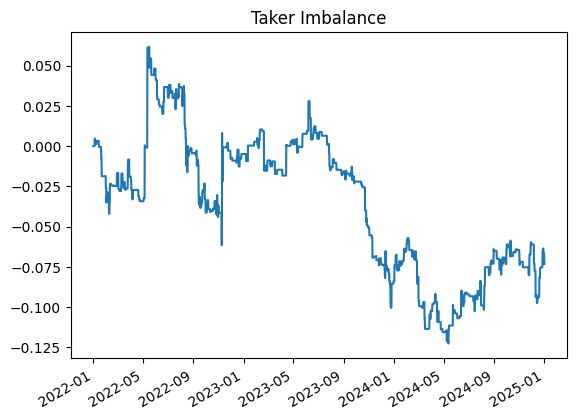

In [234]:
strat_ret = weights*ret

# Backtest metrics
cum_rets = strat_ret.sum(axis=1).cumsum()
sharpe = strat_ret.mean(axis=1).mean() / strat_ret.mean(axis=1).std() * np.sqrt((24/num_hours)*365)
total_ret = cum_rets.iloc[-1]
max_dd = (cum_rets - cum_rets.cummax()).min()

print(f'Total Return: {total_ret:.2%}')
print(f'Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2%}')
print(f'Hit Rate:     {(strategy_rets_2.mean(axis=1) > 0).mean():.2%}')

cum_rets.plot(title='Taker Imbalance')

# Next Strat: investigating correlation/pairs trading

also, grabbing more coin data, and removing XRP because it lacked half the data

In [ ]:
start_time = '2022-01-01T00:00:00Z'
end_time = '2025-01-01T00:00:00Z'

from binance.client import Client as bnb_client
import pandas as pd

cols = ['close', 'volume', 'quote_volume', 'num_trades', 'taker_base_volume', 'taker_quote_volume']

client = bnb_client(tld='US')
def get_binance_px(symbol, freq, start, end):
    data = client.get_historical_klines(symbol, freq, start, end)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    
    # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    data['open_time'] = pd.to_datetime(data['open_time'], unit='ms')
    data['close_time'] = pd.to_datetime(data['close_time'], unit='ms')
    data = data.set_index('open_time')
    return data 

# TRXUSDT has no data after roughly early 2023
# MUSDT, HYPEUSDT, XMRUSDT, LEOUSDT all invalid/no data
univ = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'ADAUSDT', 'BNBUSDT', 'LINKUSDT', 'SHIBUSDT', 'DOGEUSDT']

freq = '1h'
px = pd.DataFrame().astype(float)

all_data = []
for x in univ:
    data = get_binance_px(x ,freq, start_time, end_time)
    data = data[cols]
    data.columns = pd.MultiIndex.from_product([[x], data.columns])
    all_data.append(data)

px = pd.concat(all_data, axis=1)
px = px.reindex(pd.date_range(px.index[0],px.index[-1],freq=freq))
px = px.astype(float)
ret = px.xs('close', axis=1, level=1).astype(float).pct_change()

ret.to_pickle('crypto_returns_2022_to_2025')
px.to_pickle('crypto_data_more_2022_to_2025')

/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/1427269530.py:41: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = px.xs('close', axis=1, level=1).astype(float).pct_change()


In [2]:
import pandas as pd
px = pd.read_pickle('crypto_data_more_2022_to_2025')
ret = pd.read_pickle('crypto_returns_more_2022_to_2025')

<Axes: >

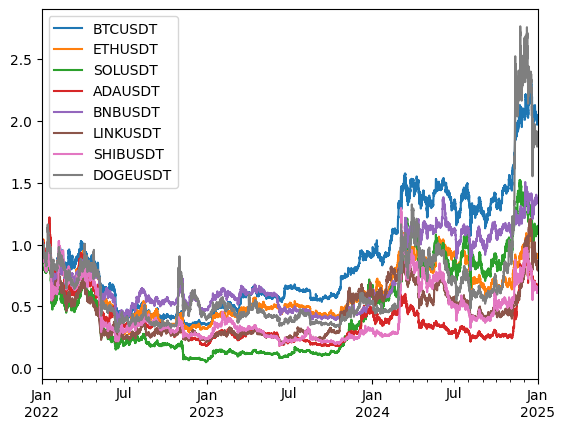

In [394]:
(1+ret).cumprod().plot()

In [395]:
# 1. compute something you think might matter
factor = ret.rolling(6).mean()   # e.g. momentum, vol, imbalance, anything

# 2. rank it cross-sectionally into quintiles
ranked = factor.rank(axis=1).shift(1)

# with 9 tickers ranks are 1-9, split into thirds
bottom = ret[ranked <= 3].mean(axis=1).mean()
middle = ret[(ranked > 3) & (ranked <= 6)].mean(axis=1).mean()
top    = ret[ranked > 6].mean(axis=1).mean()

print(f"bottom: {bottom:.6f}")
print(f"middle: {middle:.6f}")
print(f"top: {top:.6f}")

ranked = factor.rank(axis=1).shift(1)

# 3. look at average forward return per rank
for r in range(1, 10):
    avg_ret = ret[ranked == r].mean(axis=1).mean()
    print(f"rank {r}: {avg_ret:.6f}")



bottom: 0.000222
middle: -0.000028
top: -0.000113
rank 1: 0.000372
rank 2: 0.000210
rank 3: 0.000084
rank 4: 0.000017
rank 5: -0.000007
rank 6: -0.000094
rank 7: -0.000120
rank 8: -0.000107
rank 9: nan


In [338]:
ret.corr()

,BTCUSDT,ETHUSDT,SOLUSDT,ADAUSDT,BNBUSDT,LINKUSDT,SHIBUSDT,DOGEUSDT
BTCUSDT,1.000000,0.851462,0.709658,0.695150,0.716320,0.682977,0.628015,0.643027
ETHUSDT,0.851462,1.000000,0.721505,0.721448,0.742452,0.734939,0.643488,0.657605
SOLUSDT,0.709658,0.721505,1.000000,0.669501,0.650473,0.663808,0.586204,0.598638
ADAUSDT,0.695150,0.721448,0.669501,1.000000,0.660994,0.692061,0.633561,0.632636
BNBUSDT,0.716320,0.742452,0.650473,0.660994,1.000000,0.664665,0.593665,0.605356
LINKUSDT,0.682977,0.734939,0.663808,0.692061,0.664665,1.000000,0.596793,0.611112
SHIBUSDT,0.628015,0.643488,0.586204,0.633561,0.593665,0.596793,1.000000,0.737901
DOGEUSDT,0.643027,0.657605,0.598638,0.632636,0.605356,0.611112,0.737901,1.000000


<Axes: >

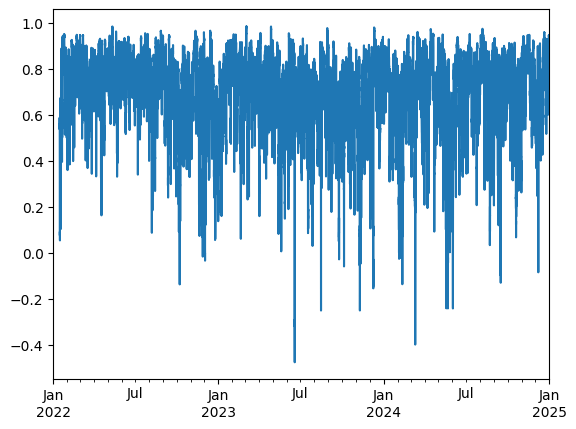

In [396]:
# pick a pair
ret['LINKUSDT'].rolling(24).corr(ret['ETHUSDT']).plot()

const   -5.899284
close    1.072451
dtype: float64


/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/152449082.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spread = log_link - model.params[1] * log_eth - model.params[0]


<Axes: title={'center': 'BTC/ETH spread'}>

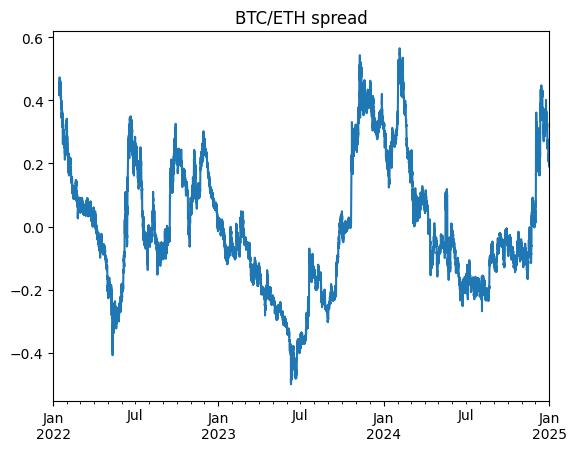

In [1484]:
import statsmodels.api as sm

log_link = np.log(px['LINKUSDT']['close'].astype(float))
log_eth = np.log(px['ETHUSDT']['close'].astype(float))

log_prices = pd.concat([log_link, log_eth], axis=1).dropna()
log_link = log_prices.iloc[:, 0]
log_eth = log_prices.iloc[:, 1]
# modelling log(link returns) = a + b * log(eth returns)

model = sm.OLS(log_link, sm.add_constant(log_eth)).fit()
print(model.params)
# high spread means LINK is expensive relative to ETH, so short LINK
spread = log_link - model.params[1] * log_eth - model.params[0]
spread = spread.reindex(ret.index)
spread.plot(title='BTC/ETH spread')

In [1485]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(spread.dropna())
print(f"ADF statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")

ADF statistic : -2.8226
p-value       : 0.0551


good candidates for pairs trading

LINK v ETH: p = 0.05...

SOL v ETH p = 0.06...

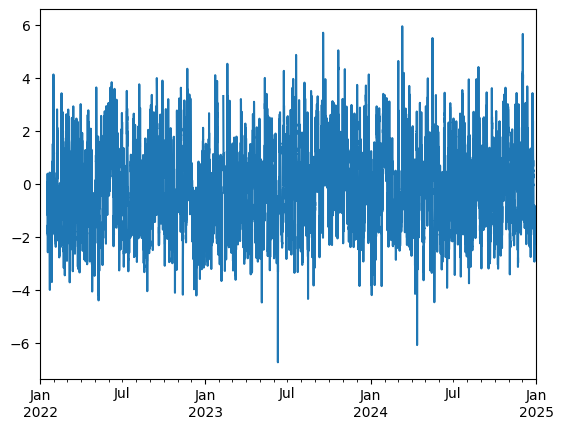

In [1493]:
spread_z = (spread - spread.rolling(72).mean()) / spread.rolling(72).std()
threshold=2
spread_z.plot()

# entry signal only — fires at threshold, NaN in between
entry = np.select(
    [spread_z > threshold, spread_z < -threshold],
    [-1, 1],
    default=np.nan
)

# convert to series, forward fill (hold position), exit at zero crossing
signal = pd.Series(entry, index=spread_z.index)
signal = signal.ffill()

# exit when spread crosses back through zero
signal[spread_z.abs() < threshold*.7] = 0   # flat zone around zero
signal = signal.fillna(0)

positions = pd.concat([signal, -signal], axis=1)
positions.columns = ['LINKUSDT', 'ETHUSDT']
positions = positions.divide(positions.abs().sum(axis=1), axis=0).fillna(0)

<Axes: title={'center': 'LINK/ETH pairs trade'}>

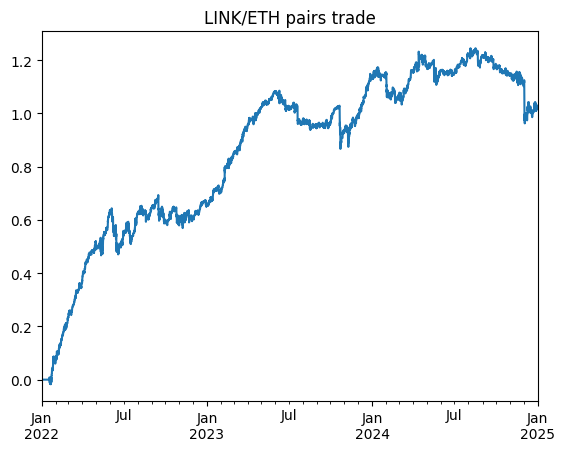

In [1494]:
common_idx = positions.index.intersection(ret.index)
strat_pairs = (positions.shift(1).loc[common_idx]* ret.loc[common_idx, ['LINKUSDT', 'ETHUSDT']]).sum(axis=1)
strat_pairs.cumsum().plot(title='LINK/ETH pairs trade')

In [1495]:
print(sharpe(strat_pairs))

turnover = 0.5*positions.diff().abs().sum(axis=1)
cost = turnover * 0.002
net_pnl = strat_pairs - cost
print(sharpe(net_pnl))

# to = 0.5*(positions - positions.shift()).abs().sum(axis=1)
# tcost_bps = 10 # (estimate of avg commissions + avg slippage)
# net_ret = strat_pairs.subtract(to*tcost_bps*1e-4)
# print(sharpe(net_ret))

1.6446226545746983
-4.267224770162848


In [1087]:
positions.head(5000).tail(20)

,LINKUSDT,ETHUSDT
2022-07-27 12:00:00,0.5,-0.5
2022-07-27 13:00:00,0.5,-0.5
2022-07-27 14:00:00,0.5,-0.5
2022-07-27 15:00:00,0.5,-0.5
2022-07-27 16:00:00,0.5,-0.5
2022-07-27 17:00:00,0.5,-0.5
2022-07-27 18:00:00,0.5,-0.5
2022-07-27 19:00:00,0.5,-0.5
2022-07-27 20:00:00,0.5,-0.5
2022-07-27 21:00:00,0.5,-0.5


In [1028]:
positions.diff().head(5000).tail(20)

,LINKUSDT,ETHUSDT
2022-07-27 12:00:00,0.0,0.0
2022-07-27 13:00:00,0.0,0.0
2022-07-27 14:00:00,0.0,0.0
2022-07-27 15:00:00,0.0,0.0
2022-07-27 16:00:00,0.0,0.0
2022-07-27 17:00:00,0.0,0.0
2022-07-27 18:00:00,0.0,0.0
2022-07-27 19:00:00,0.0,0.0
2022-07-27 20:00:00,0.0,0.0
2022-07-27 21:00:00,0.0,0.0


In [1019]:
(positions.ffill() - positions.ffill().shift())

,LINKUSDT,ETHUSDT
2022-01-01 00:00:00,NaN,NaN
2022-01-01 01:00:00,NaN,NaN
2022-01-01 02:00:00,NaN,NaN
2022-01-01 03:00:00,NaN,NaN
2022-01-01 04:00:00,NaN,NaN
...,...,...
2024-12-31 20:00:00,0.0,0.0
2024-12-31 21:00:00,0.0,0.0
2024-12-31 22:00:00,0.0,0.0
2024-12-31 23:00:00,0.0,0.0


<Axes: >

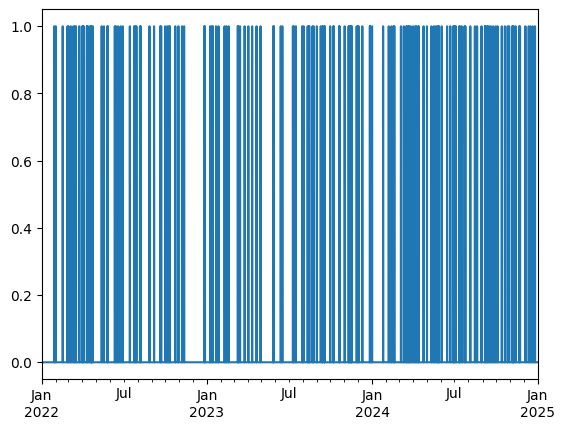

In [1002]:
turnover.plot()

In [2136]:
def sharpe(s, num_hours=1):
    periods_per_year = (24 / num_hours) * 365
    return s.mean() / s.std() * np.sqrt(periods_per_year)

# Next Strat: trying pairs trading again but at longer time frame

In [1469]:
num_hours = 4
px_h = px.resample(str(num_hours)+'h').first()
ret_h = px_h.xs('close', axis=1, level=1).pct_change()

/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/1445749131.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_h = px_h.xs('close', axis=1, level=1).pct_change()


In [1470]:
import statsmodels.api as sm

log_link = np.log(px_h['LINKUSDT']['close'].astype(float))
log_eth = np.log(px_h['ETHUSDT']['close'].astype(float))

log_prices = pd.concat([log_link, log_eth], axis=1).dropna()
log_link = log_prices.iloc[:, 0]
log_eth = log_prices.iloc[:, 1]
# modelling log(link returns) = a + b * log(eth returns)

model = sm.OLS(log_link, sm.add_constant(log_eth)).fit()
print(model.params)
spread = log_link - model.params[1] * log_eth - model.params[0]
spread = spread.reindex(ret_h.index)
# spread.plot(title='LINK/ETH spread')

const   -5.900855
close    1.072657
dtype: float64


/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/1932315294.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spread = log_link - model.params[1] * log_eth - model.params[0]


In [1471]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(spread.dropna())
print(f"ADF statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")

ADF statistic : -2.8944
p-value       : 0.0460


<Axes: >

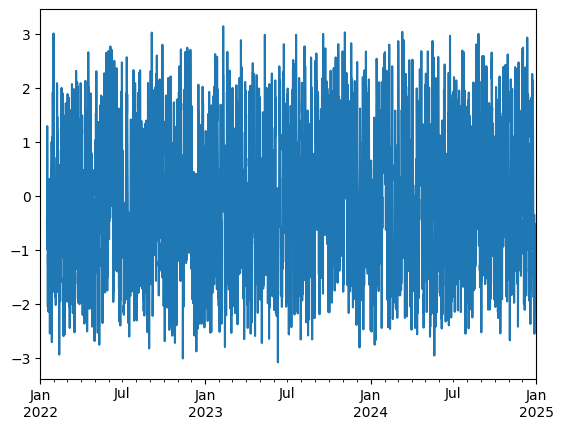

In [1472]:
spread_z = (spread - spread.rolling(12).mean())/spread.rolling(12).std()
spread_z.plot()

In [1480]:
threshold=1.5

# entry signal only — fires at threshold, NaN in between
entry = np.select(
    [spread_z > threshold, spread_z < -threshold],
    [1, -1],
    default=np.nan
)

# convert to series, forward fill (hold position), exit at zero crossing
signal = pd.Series(entry, index=spread_z.index)
signal = signal.ffill()

# exit when spread crosses back through zero
signal[spread_z.abs() < 0.1] = 0   # flat zone around zero
signal = signal.fillna(0)

positions = pd.concat([signal, -signal], axis=1)
positions.columns = ['LINKUSDT', 'ETHUSDT']
positions = positions.div(positions.abs().sum(axis=1), axis=0).fillna(0)

<Axes: title={'center': 'LINK/ETH pairs trade'}>

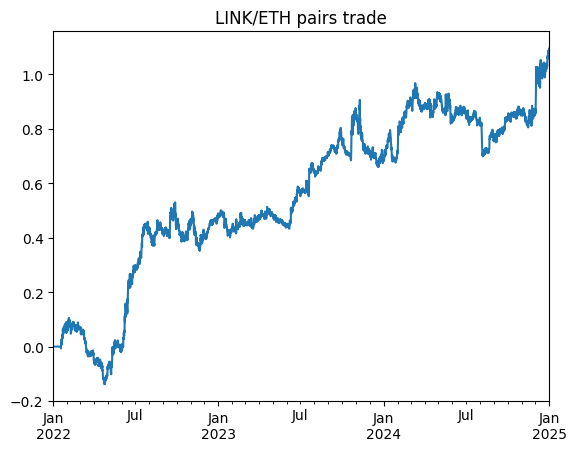

In [1481]:
common_idx = positions.index.intersection(ret_h.index)
strat_pairs = (positions.shift(1).loc[common_idx]* ret_h.loc[common_idx, ['LINKUSDT', 'ETHUSDT']]).sum(axis=1)
strat_pairs.cumsum().plot(title='LINK/ETH pairs trade')

In [1483]:
print(sharpe(strat_pairs, num_hours))

turnover = 0.5*positions.diff().abs().sum(axis=1)
cost = turnover * 0.002
net_pnl = strat_pairs - cost
print(sharpe(net_pnl, num_hours))


1.2386671608032087
0.004469317359810325


# Next strat: Twitter data but with more cryptos

In [15]:
import pandas as pd
df_tweets = pd.read_pickle('crypto_tweets_2022_to_2025')
px = pd.read_pickle('crypto_data_more_2022_to_2025')
ret = pd.read_pickle('crypto_returns_more_2022_to_2025')

In [16]:
df_tweets.head()

,btc_count,eth_count,alt_count
2022-01-01 00:00:00,3804,6446,3663
2022-01-01 01:00:00,3494,5047,3138
2022-01-01 02:00:00,2972,6668,2827
2022-01-01 03:00:00,3333,6726,2709
2022-01-01 04:00:00,3356,7080,2508


In [17]:
ret.head()

,BTCUSDT,ETHUSDT,SOLUSDT,ADAUSDT,BNBUSDT,LINKUSDT,SHIBUSDT,DOGEUSDT
2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:00:00,0.002362,0.000965,-0.000244,-0.000925,-0.000425,NaN,-0.001183,-0.000497
2022-01-01 02:00:00,-0.000093,0.001630,0.002401,-0.001747,0.001075,NaN,-0.002072,-0.001320
2022-01-01 03:00:00,0.000985,-0.001370,-0.000292,-0.000830,0.000593,NaN,-0.001187,-0.000967
2022-01-01 04:00:00,-0.001968,-0.004987,-0.007844,-0.012008,-0.006439,NaN,-0.007425,-0.006893


In [18]:
num_hours = 4
freq_str = f"{num_hours}h"
df_tweets = df_tweets.resample(freq_str).sum()
px = px.resample(freq_str).first()
ret = ret.resample(freq_str).first()

In [19]:
span = 3

btc_z = (df_tweets['btc_count'] - df_tweets['btc_count'].ewm(span=span).mean()) / df_tweets['btc_count'].ewm(span=span).std()
eth_z = (df_tweets['eth_count'] - df_tweets['eth_count'].ewm(span=span).mean()) / df_tweets['eth_count'].ewm(span=span).std()
alt_z = (df_tweets['alt_count'] - df_tweets['alt_count'].ewm(span=span).mean()) / df_tweets['alt_count'].ewm(span=span).std()


In [20]:
relative_signal = ((btc_z+eth_z)/2 - alt_z)
relative_signal = (relative_signal - relative_signal.rolling(12).mean()) / relative_signal.rolling(12).std()
relative_signal = np.tanh(relative_signal)
relative_signal.hist(bins=50)

NameError: name 'np' is not defined

<Axes: >

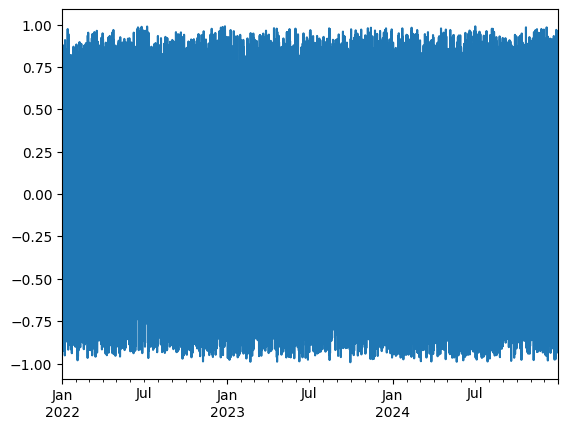

In [1598]:
relative_signal.plot()

<Axes: >

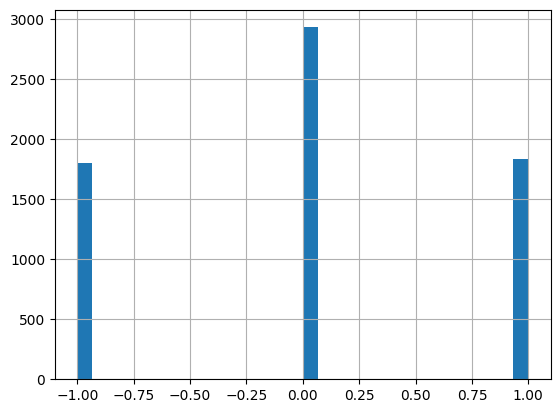

In [1599]:
positions = relative_signal.copy(True)
threshold = 0.6
positions[positions>threshold] = 1
positions[positions<-threshold] = -1
positions[(positions<threshold) & (-threshold<positions)] = 0
positions.hist(bins=30)

In [1600]:
positions = positions.fillna(0)

<Axes: >

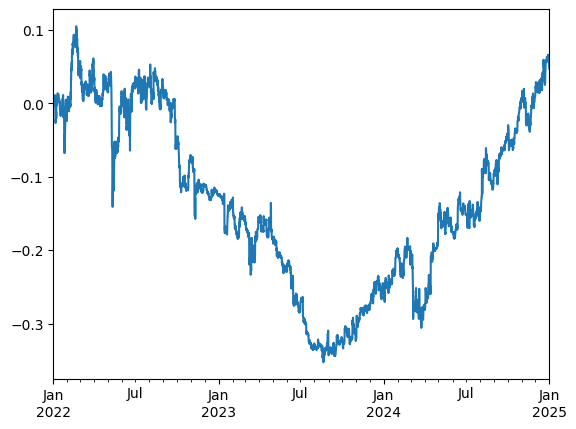

In [1601]:
strat_ret = positions.shift(1)*ret['BTCUSDT']
strat_ret.cumsum().plot()

In [1602]:
print(sharpe(strat_ret, num_hours))

# turnover = 0.5*positions.diff().abs().sum(axis=1)
# cost = turnover * 0.002
# net_pnl = strat_ret - cost
# print(sharpe(net_pnl, num_hours))

0.0801370047762442


# Next Strat: Momentum strat on alts

<Axes: >

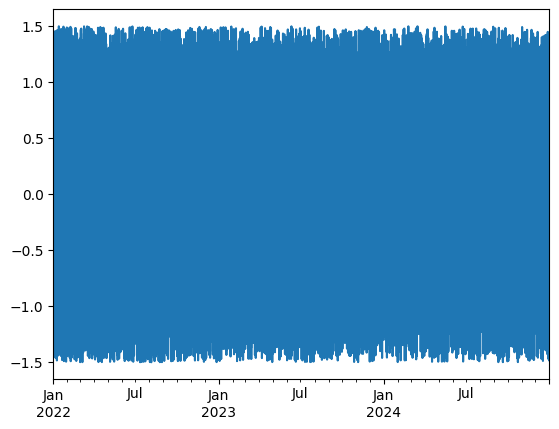

In [1697]:
signal = (alt_z - (btc_z+eth_z)/2).rolling(6).mean()
signal = (signal - signal.rolling(4).mean())/signal.rolling(4).std()
signal.plot()

In [1686]:
alt = ['SOLUSDT', 'ADAUSDT', 'BNBUSDT', 'LINKUSDT', 'SHIBUSDT', 'DOGEUSDT']
ranked = ret[alt].rolling(12).mean().rank(axis=1)
ranked = ranked.subtract(ranked.mean(axis=1), axis=0)
ranked = ranked.divide(ranked.abs().sum(axis=1), axis=0)
weights = ranked.iloc[:-1]

In [1687]:
weights[signal>0.6] = 0
weights[signal<-0.6] = 0

/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/1958201908.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weights[signal>0.6] = 0
/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/1958201908.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weights[signal>0.6] = 0
/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/1958201908.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

In [1688]:
strat = (weights.shift()*ret[alt]).sum(axis=1)

In [1689]:
print(sharpe(strat, num_hours))

turnover = weights.diff().abs().sum(axis=1)
cost = turnover * 0.002
net_pnl = strat - cost
print(sharpe(net_pnl, num_hours))

0.5588991172012702
-12.187646190842758


<Axes: >

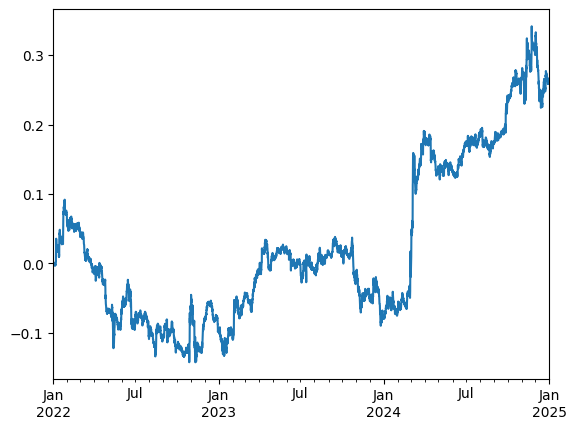

In [1690]:
strat.cumsum().plot()

# Next Strat: More twitter data for altcoins

## Gathering Data

In [ ]:
from xdk import Client
import pandas as pd
import numpy as np

client = Client(bearer_token="AAAAAAAAAAAAAAAAAAAAAKZX8gEAAAAAKEtxgn4Z2DU9yHk3WI2xMW4p%2BKo%3DGiZFyIcHOEd9FE0d1FuNMAQ8ZLyEFFdcg9OLoZ9OJgNerNRkID")

granularity = 'hour'

# Count past bitcoin-related posts
btc_posts = client.posts.get_counts_all(
    query="(bitcoin OR btc) lang:en -is:retweet",
    start_time=start_time,
    end_time=end_time,
    granularity=granularity
)

# Count past ethereum-related posts
eth_posts = client.posts.get_counts_all(
    query="(ethereum OR eth) lang:en -is:retweet",
    start_time=start_time,
    end_time=end_time,
    granularity=granularity
)


# Count past altcoin-related posts
altcoin_posts = client.posts.get_counts_all(
    query='(solana OR SOL OR cardano OR ADA OR "binance coin" OR BNB OR chainlink OR LINK OR SHIB OR dogecoin OR DOGE) lang:en -is:retweet',
    start_time=start_time,
    end_time=end_time,
    granularity=granularity
)

In [ ]:
from xdk import Client
import pandas as pd
import numpy as np

client = Client(bearer_token="AAAAAAAAAAAAAAAAAAAAAKZX8gEAAAAAY89ISCn49CuHQrBnAtfeQrClAso%3DGbDhhGk3v7pkxbFeKI8a2JA2evghn46S9o6WpCIicaWij2n0pJ")

granularity = 'hour'

start_time = '2022-01-01T00:00:00Z'
end_time = '2025-01-01T00:00:00Z'

queries = {
    'BTC':  '(bitcoin OR $BTC) lang:en -is:retweet',
    'ETH':  '(ethereum OR $ETH) lang:en -is:retweet',
    'SOL':  '(solana OR $SOL) lang:en -is:retweet',
    'ADA':  '(cardano OR $ADA) lang:en -is:retweet',
    'BNB':  '("binance coin" OR $BNB) lang:en -is:retweet',
    'LINK': '(chainlink OR $LINK) lang:en -is:retweet',
    'SHIB': '($SHIB OR "shiba inu coin") lang:en -is:retweet',
    'DOGE': '(dogecoin OR $DOGE) lang:en -is:retweet',
    'AVAX': '(avalanche OR $AVAX) lang:en -is:retweet',
    'DOT':  '(polkadot OR $DOT) lang:en -is:retweet',
    'UNI':  '(uniswap OR $UNI) lang:en -is:retweet',
}

raw = {ticker: [] for ticker in queries}
dates = {'start_date': []}

for ticker, query in queries.items():
    posts = client.posts.get_counts_all(
        query=query,
        start_time=start_time,
        end_time=end_time,
        granularity=granularity
    )
    for page in posts:
        for data in page.data:
            if ticker == 'BTC':   # only populate dates once
                dates['start_date'].append(data['start'])
            raw[ticker].append(data['tweet_count'])

df_tweets = pd.DataFrame({**dates, **raw})
df_tweets['start_date'] = pd.to_datetime(df_tweets['start_date'])

In [ ]:
df_tweets = df_tweets.set_index('start_date')
df_tweets.index.name = None
df_tweets = df_tweets.sort_index()
df_tweets.index = df_tweets.index.tz_localize(None)
df_tweets = df_tweets.resample('1h').sum()
df_tweets.to_pickle('crypto_tweets_more_2022_to_2025')


In [1775]:
df_tweets = pd.read_pickle('crypto_tweets_more_2022_to_2025')

In [1821]:
df_tweets_4h = df_tweets.resample('4h').sum()
ret_4h = px.xs('close', axis=1, level=1).resample('4h').first().pct_change()

/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/1927465869.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_4h = px.xs('close', axis=1, level=1).resample('4h').first().pct_change()


## Investigations

In [1806]:
vol = ret_4h.rolling(10).std()

In [1812]:
tweets_z = (df_tweets_4h - df_tweets_4h.rolling(6).mean())/df_tweets_4h.rolling(6).std()

In [1818]:
for ticker in ['BTC', 'ETH', 'SOL',	'ADA', 'BNB', 'LINK', 'SHIB', 'DOGE']:
    print(tweets_z[ticker].shift().corr(vol[f'{ticker}USDT']))

-0.020094535082696943
-0.006536713310073126
-0.015089043273016873
0.003386344425850892
-0.0031594695980354105
0.0004466789780847154
0.014430988962887123
-0.010925148571940718


In [1823]:
tweets_z.corr()

,BTC,ETH,SOL,ADA,BNB,LINK,SHIB,DOGE,AVAX,DOT,UNI
BTC,1.000000,-0.267276,-0.208058,0.191355,-0.251785,-0.085716,0.208774,0.445098,0.269832,0.482174,0.347202
ETH,-0.267276,1.000000,0.056901,-0.307505,0.142724,0.198299,-0.203553,-0.197650,-0.130875,-0.190001,-0.162344
SOL,-0.208058,0.056901,1.000000,0.120841,0.268589,-0.094235,-0.057150,-0.170404,-0.061743,-0.203422,-0.177555
ADA,0.191355,-0.307505,0.120841,1.000000,0.150911,0.072473,0.466589,0.119923,0.074432,0.114559,0.084676
BNB,-0.251785,0.142724,0.268589,0.150911,1.000000,0.234608,0.154564,-0.162874,-0.101901,-0.204180,-0.184634
LINK,-0.085716,0.198299,-0.094235,0.072473,0.234608,1.000000,0.184126,-0.077340,-0.101234,-0.062770,-0.063687
SHIB,0.208774,-0.203553,-0.057150,0.466589,0.154564,0.184126,1.000000,0.130477,0.089365,0.132004,0.114095
DOGE,0.445098,-0.197650,-0.170404,0.119923,-0.162874,-0.077340,0.130477,1.000000,0.394932,0.597831,0.387829
AVAX,0.269832,-0.130875,-0.061743,0.074432,-0.101901,-0.101234,0.089365,0.394932,1.000000,0.395695,0.263585
DOT,0.482174,-0.190001,-0.203422,0.114559,-0.204180,-0.062770,0.132004,0.597831,0.395695,1.000000,0.434233


In [1824]:
ret_4h.corr()

,BTCUSDT,ETHUSDT,SOLUSDT,ADAUSDT,BNBUSDT,LINKUSDT,SHIBUSDT,DOGEUSDT
BTCUSDT,1.000000,0.859031,0.724778,0.708938,0.735535,0.703766,0.628694,0.659176
ETHUSDT,0.859031,1.000000,0.730443,0.728745,0.761086,0.750461,0.632192,0.657360
SOLUSDT,0.724778,0.730443,1.000000,0.680026,0.681302,0.683377,0.585361,0.610487
ADAUSDT,0.708938,0.728745,0.680026,1.000000,0.685050,0.716550,0.636814,0.647136
BNBUSDT,0.735535,0.761086,0.681302,0.685050,1.000000,0.687040,0.603829,0.621249
LINKUSDT,0.703766,0.750461,0.683377,0.716550,0.687040,1.000000,0.597540,0.616074
SHIBUSDT,0.628694,0.632192,0.585361,0.636814,0.603829,0.597540,1.000000,0.764723
DOGEUSDT,0.659176,0.657360,0.610487,0.647136,0.621249,0.616074,0.764723,1.000000


<Axes: >

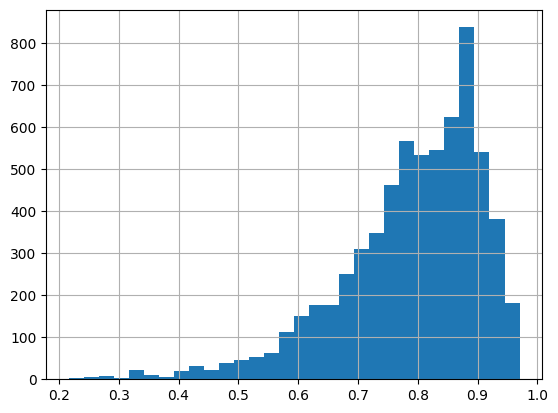

In [1828]:
ret_4h['SHIBUSDT'].rolling(42).corr(ret_4h['DOGEUSDT']).hist(bins=30)

In [2090]:
px_4h = px.resample('4h').last()

In [2091]:
import statsmodels.api as sm

for ticker_1 in ['BTC', 'ETH', 'SOL', 'ADA', 'BNB', 'LINK', 'SHIB', 'DOGE']:
    for ticker_2 in ['BTC', 'ETH', 'SOL', 'ADA', 'BNB', 'LINK', 'SHIB', 'DOGE']:
        if ticker_1 == ticker_2:
            continue
        print(ticker_1, ticker_2)
        log_Y = np.log(px_h[f'{ticker_1}USDT']['close'].astype(float))
        log_X = np.log(px_h[f'{ticker_2}USDT']['close'].astype(float))

        log_prices = pd.concat([log_Y, log_X], axis=1).dropna()
        log_Y = log_prices.iloc[:, 0]
        log_X = log_prices.iloc[:, 1]

        # modelling log(link returns) = a + b * log(eth returns)
        model = sm.OLS(log_Y, sm.add_constant(log_X)).fit()
        # print(model.params)
        spread = log_Y - model.params[1] * log_X - model.params[0]
        spread = spread.reindex(ret_h.index)
        # print(spread.autocorr())

        from statsmodels.tsa.stattools import adfuller

        result = adfuller(spread.dropna())
        # print(f"ADF statistic : {result[0]:.4f}")
        print(f"p-value       : {result[1]}")

BTC ETH


/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/782313632.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spread = log_Y - model.params[1] * log_X - model.params[0]


p-value       : 0.07290264309795637
BTC SOL
p-value       : 0.4155580920114423
BTC ADA


/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/782313632.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spread = log_Y - model.params[1] * log_X - model.params[0]
/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/782313632.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spread = log_Y - model.params[1] * log_X - model.params[0]


p-value       : 0.9239869260846496
BTC BNB
p-value       : 0.5208162354515878
BTC LINK


...

/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/782313632.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spread = log_Y - model.params[1] * log_X - model.params[0]
/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/782313632.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spread = log_Y - model.params[1] * log_X - model.params[0]


p-value       : 0.6695553459996828
DOGE BNB
p-value       : 0.07483457529813163
DOGE LINK


/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/782313632.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spread = log_Y - model.params[1] * log_X - model.params[0]
/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/782313632.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spread = log_Y - model.params[1] * log_X - model.params[0]


p-value       : 0.29240312312818845
DOGE SHIB
p-value       : 0.6494360714436193


/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/782313632.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spread = log_Y - model.params[1] * log_X - model.params[0]


amazing candidates for pairs trading

SHIB BNB (p-value 0.014)
SHIB SOL (p-value 0.034)
LINK SOL (p-value 0.011)
LINK ETH (p-value 0.046)
LINK BTC (p-value 0.004)
ETH SOL  (p-value 0.046)
ETH BTC  (p-value 0.007)


In [2130]:
ticker_1 = 'ETH'
ticker_2 = 'SOL'

log_Y = np.log(px_h[f'{ticker_1}USDT']['close'].astype(float))
log_X = np.log(px_h[f'{ticker_2}USDT']['close'].astype(float))

log_prices = pd.concat([log_Y, log_X], axis=1).dropna()
log_Y = log_prices.iloc[:, 0]
log_X = log_prices.iloc[:, 1]

# modelling log(link returns) = a + b * log(eth returns)
model = sm.OLS(log_Y, sm.add_constant(log_X)).fit()
# print(model.params)
spread = log_Y - model.params[1] * log_X - model.params[0]
spread = spread.reindex(ret_h.index)
# print(spread.autocorr())

from statsmodels.tsa.stattools import adfuller

result = adfuller(spread.dropna())
# print(f"ADF statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]}")

p-value       : 0.035141234543045706


/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/1832094253.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spread = log_Y - model.params[1] * log_X - model.params[0]


<Axes: >

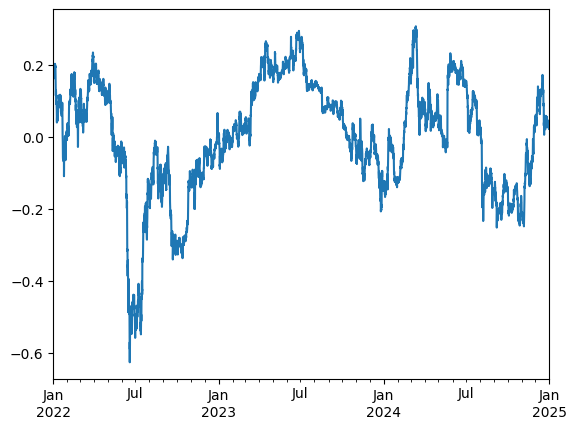

In [2131]:
spread.plot()

<Axes: >

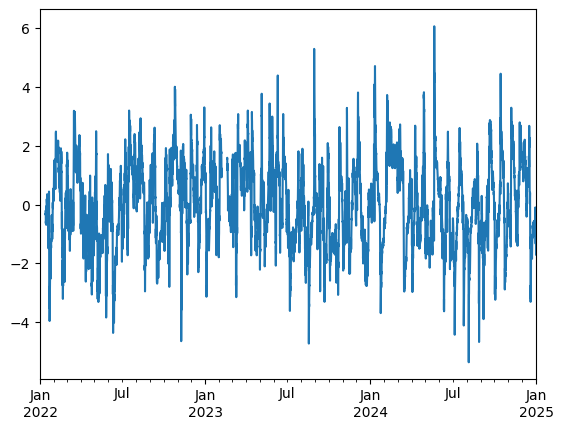

In [2132]:
spread_z = (spread - spread.rolling(72).mean())/spread.rolling(72).std()
spread_z.plot()

In [2133]:
threshold = 1.8
exit_threshold = threshold * 1

signal = pd.Series(0, index=spread_z.index)
signal[spread_z>threshold] = 1
signal[spread_z<-threshold] = -1
signal = signal.replace(0, np.nan).ffill()
signal[spread_z.abs() < exit_threshold] = 0
signal = signal.shift(1).fillna(0)

positions = pd.concat([
    signal,             
    -model.params[1] * signal
], axis=1)
positions.columns = [f'{ticker_1}USDT', f'{ticker_2}USDT']
positions = positions.divide(positions.abs().sum(axis=1), axis=0).fillna(0)

/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/402482594.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  -model.params[1] * signal


np.float64(0.7723978884083863)

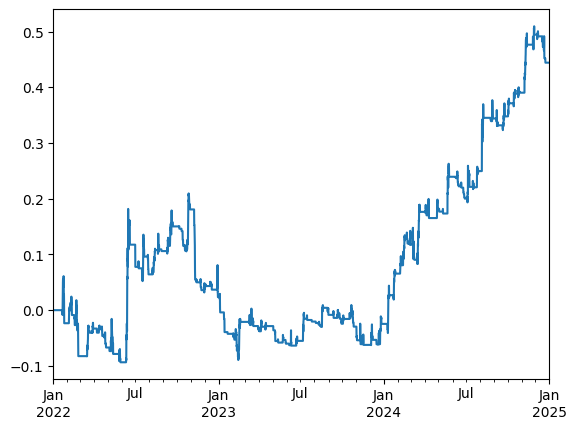

In [2134]:
pnl = (positions*ret_4h[[f'{ticker_1}USDT', f'{ticker_2}USDT']]).sum(axis=1)
pnl.cumsum().plot()
sharpe(pnl, 4)

<Axes: >

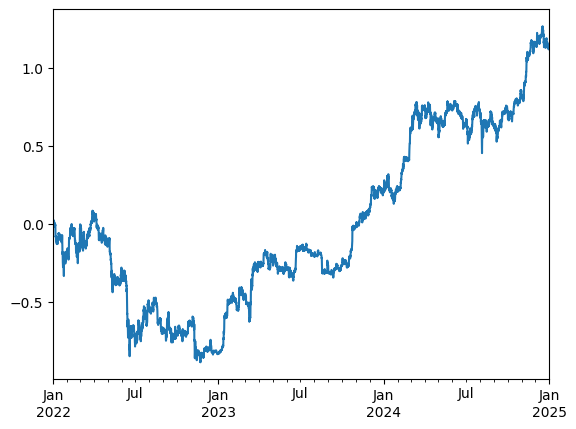

In [2089]:

# print(sharpe(ret_4h[[f'{ticker_1}USDT', f'{ticker_2}USDT']]['july 1st 2023':], 4))
# ret_4h[[f'{ticker_1}USDT', f'{ticker_2}USDT']]['july 1st 2023':].cumsum().plot()
ret_4h['BTCUSDT'].cumsum().plot()

# Next Strat: Average Trade Size

gross sharpe : 0.50
net sharpe   : -14.86
max drawdown : -100.0%
avg turnover : 1.238 per bar


/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/985345524.py:12: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = close.pct_change()


<Axes: title={'center': 'avg trade size strategy'}>

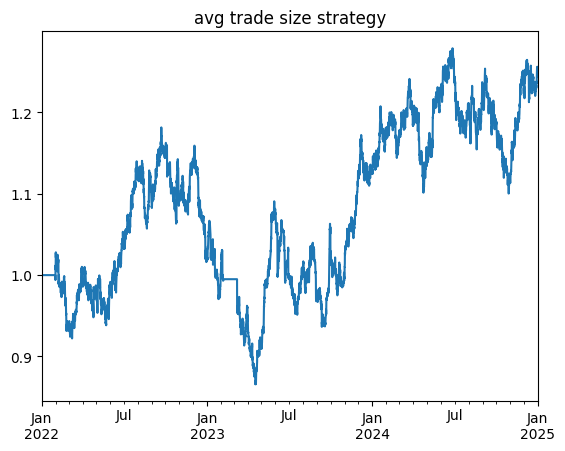

In [2137]:
NUM_HOURS  = 4
FREQ       = f'{NUM_HOURS}h'
VOL_WINDOW = 21          # 1 week of 4h bars
Z_WINDOW   = 180         # ~1 month for z-score baseline
FEE        = 0.001
PERIODS_PER_YEAR = (24 / NUM_HOURS) * 365

close        = px.xs('close',              axis=1, level=1).astype(float).resample(FREQ).last()
quote_vol    = px.xs('quote_volume',       axis=1, level=1).astype(float).resample(FREQ).sum()
taker_quote  = px.xs('taker_quote_volume', axis=1, level=1).astype(float).resample(FREQ).sum()
num_trades   = px.xs('num_trades',         axis=1, level=1).astype(float).resample(FREQ).sum()
ret = close.pct_change()

 
buy_vol      = taker_quote
sell_vol     = quote_vol - taker_quote
imbalance    = (buy_vol - sell_vol) / quote_vol


avg_trade_size = quote_vol / num_trades                # USDT per trade
 
# z-score relative to rolling history — is this unusually large or small?
avg_trade_z = (
    avg_trade_size
    .subtract(avg_trade_size.rolling(Z_WINDOW).mean(), axis=0)
    .divide(avg_trade_size.rolling(Z_WINDOW).std(), axis=0)
)

signal = avg_trade_z * imbalance

from scipy.stats import norm
 
def rank_normal(df):
    r = df.rank(axis=1)
    scaled = r.divide(r.shape[1] + 1)
    return scaled.apply(norm.ppf)
 
signal = rank_normal(signal)
signal = signal.subtract(signal.mean(axis=1), axis=0)
signal = signal.divide(signal.abs().sum(axis=1), axis=0)
weights = signal.shift(1)

gross_ret  = (weights * ret).sum(axis=1)
port_vol   = gross_ret.rolling(VOL_WINDOW).std().shift(1) * np.sqrt(PERIODS_PER_YEAR)
vol_scalar = (0.15 / port_vol).clip(0, 3)
scaled_ret = gross_ret * vol_scalar

turnover = weights.diff().abs().sum(axis=1)
net_ret  = scaled_ret - turnover * FEE

def max_dd(s):
    cum = (1 + s).cumprod()
    return (cum / cum.cummax() - 1).min()
 
print(f"gross sharpe : {sharpe(gross_ret, NUM_HOURS):.2f}")
print(f"net sharpe   : {sharpe(net_ret, NUM_HOURS):.2f}")
print(f"max drawdown : {max_dd(net_ret):.1%}")
print(f"avg turnover : {turnover.mean():.3f} per bar")

(1 + scaled_ret).cumprod().plot(title='avg trade size strategy')


# Next Strat: testing the weekend effect

In [2140]:
is_weekend = pd.Series(ret_4h.index.dayofweek >= 5, index=ret.index)
is_active_hours = pd.Series(ret_4h.index.hour.isin(range(13, 22)), index=ret.index)  # 1pm-10pm UTC = US hours

In [2155]:
print(sharpe(gross_ret[is_weekend], 4))
print(sharpe(gross_ret[~is_weekend], 4))

-0.8895736259817517
1.012665195983734


<Axes: title={'center': 'IC by hour of day'}>

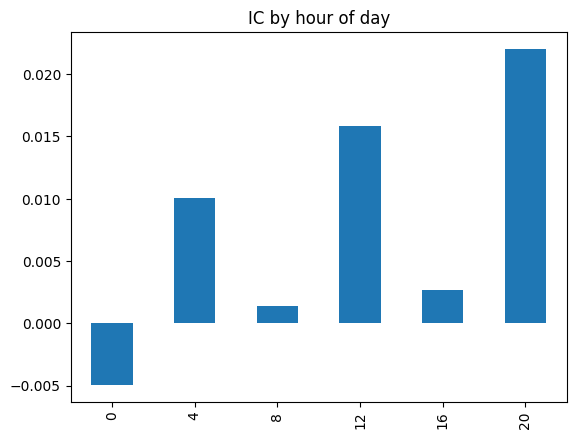

In [2144]:
ic = signal.shift(1).corrwith(ret, axis=1)
ic.groupby(ic.index.hour).mean().plot(kind='bar', title='IC by hour of day')

<Axes: title={'center': 'avg tweet volume by hour'}>

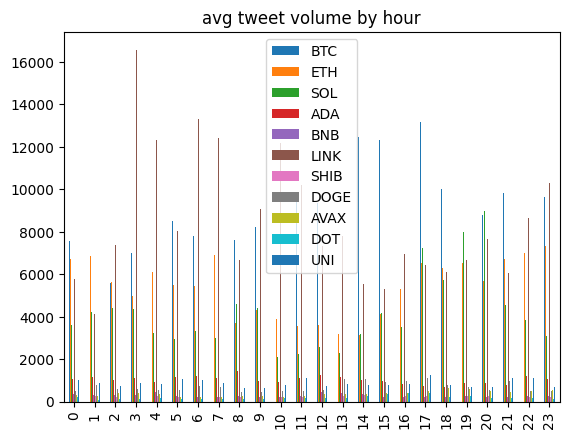

In [2150]:
df_tweets.groupby(df_tweets.index.hour).mean().plot(kind='bar', title='avg tweet volume by hour')

In [2154]:
mid = len(gross_ret) // 2
print(mid)
print(len(gross_ret))
print(sharpe(gross_ret[is_weekend].iloc[:mid], 4))
print(sharpe(gross_ret[is_weekend].iloc[mid:], 4))
print(sharpe(gross_ret[is_weekend], 4))

3288
6577
-0.8895736259817517
nan
-0.8895736259817517


In [ ]:
num_hours = 4
freq_str = str(num_hours)+'h'

df_tweets_h = df_tweets.resample(freq_str).sum()
ret_h = px.xs('close', axis=1, level=1).astype(float).resample(freq_str).last().pct_change(periods=1)

# Z-score all the tweet series
tweets_z = (df_tweets_4h - df_tweets_4h.rolling(6).mean())/df_tweets_4h.rolling(6).std()
signal = tweets_z.rank()

# strat_ret = ret_4h[]

# btc_z = tweets_z['BTC']
# eth_z = tweets_z['ETH']
# sol_z = tweets_z['SOL']
# ada_z = tweets_z['ADA']
# bnb_z = tweets_z['BNB']
# link_z = tweets_z['LINK']
# shib_z = tweets_z['SHIB']
# doge_z = tweets_z['DOGE']


market_trending_up = ((btc_ret > 0) & (eth_ret > 0)).astype(int)
high_vol = (ret_h['BTCUSDT']>ret_h['BTCUSDT'].rolling(5).median()).astype(int) # further regime filtering here

# Combined signal
signal_1 = relative_signal.shift(1) * market_trending_up.shift(1) * high_vol.shift(1)
thresh = 1
positions = signal_1.apply(lambda x: 1 if x > thresh else (-1 if x < -thresh else 0)).fillna(0)
# positions = relative_signal.clip(-2,2)


# Backtest metrics
cum_rets = strategy_rets_1.sum(axis=1).cumsum()
sharpe = strategy_rets_1.mean(axis=1).mean() / strategy_rets_1.mean(axis=1).std() * np.sqrt((24/num_hours)*365)
total_ret = cum_rets.iloc[-1]
max_dd = (cum_rets - cum_rets.cummax()).min()

print(f'Total Return: {total_ret:.2%}')
print(f'Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2%}')
print(f'Hit Rate:     {(strategy_rets_1.mean(axis=1) > 0).mean():.2%}')

cum_rets.plot(title='Alt Rotation Strategy Cumulative Return')

/var/folders/3m/q147kqhs4nv_6m8t3xn0vs540000gp/T/ipykernel_27271/2705449607.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_h = px.xs('close', axis=1, level=1).astype(float).resample(freq_str).last().pct_change(periods=1)


KeyError: 'btc_count'